# Analysis of RL Experiments

This notebook reads the PyExperimenter SQLite database directly. It includes completed runs only and analyzes step trajectories, episodes, and change detection.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

pd.set_option("display.max_columns", None)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 20,
    "figure.dpi": 120,
    "lines.linewidth": 2.0,
})
display(HTML("""
<style>
.jp-RenderedMarkdown, .jp-RenderedHTMLCommon { font-size: 16px; }
table.dataframe, table.dataframe th, table.dataframe td { font-size: 14px; }
</style>
"""))
ROLLING_WINDOW = 100
CONFIDENCE_Z = 1.96

ALGORITHM_COLORS = {
    "dyna-q": "#56B4E9",
    "dyna-q-plus": "#E69F00",
    "local-change-dyna-q": "#4D4D4D",
    "q-learning": "#7B2CBF",
    "stability-aware-dyna-q": "#D55E00",
    "stability-aware-dyna-q (decay 0.8)": "#56B4E9",
    "stability-aware-dyna-q (no decay)": "#000000",
}
ALGORITHM_LINESTYLES = {
    "stability-aware-dyna-q (decay 0.8)": "--",
    "stability-aware-dyna-q (no decay)": ":",
}
BEHAVIOR_COLORS = {
    "stationary": "#56B4E9",
    "noise": "#E69F00",
    "temporary": "#7B2CBF",
    "permanent": "#D55E00",
}

In [2]:
project_candidates = (Path.cwd(), *Path.cwd().parents)
PROJECT_ROOT = next(
    (
        path
        for path in project_candidates
        if (path / "experiments" / "pyexperimenter_results.db").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "experiments/pyexperimenter_results.db was not found"
    )

DATABASE_PATH = PROJECT_ROOT / "experiments" / "pyexperimenter_results.db"
print(f"Database: {DATABASE_PATH}")

Database: C:\Users\Merlin\Documents\Uni\Master\SoSe2026\Reinforcement Learning\exam_project\structural-change-dyna-q\experiments\pyexperimenter_results.db


In [3]:
with sqlite3.connect(DATABASE_PATH) as connection:
    runs = pd.read_sql_query(
        "SELECT * FROM structural_change_experiments",
        connection,
    )
    steps = pd.read_sql_query(
        """
        SELECT
            step.experiment_id,
            step.global_step,
            step.state_row,
            step.state_column,
            step.action,
            step.reward,
            step.model_mismatch,
            step.stability_score,
            step.observed_transition_stability,
            step.candidate_count
        FROM structural_change_experiments__steps AS step
        JOIN structural_change_experiments AS run
            ON run.ID = step.experiment_id
        WHERE run.status = 'done'
        """,
        connection,
    )

DECAY_08_ALGORITHM = "stability-aware-dyna-q (decay 0.8)"
NO_DECAY_ALGORITHM = "stability-aware-dyna-q (no decay)"
STABILITY_AWARE_VARIANTS = {
    0.0: "stability-aware-dyna-q (decay 0.0)",
    0.2: "stability-aware-dyna-q (decay 0.2)",
    0.4: "stability-aware-dyna-q (decay 0.4)",
    0.6: "stability-aware-dyna-q (decay 0.6)",
    0.8: DECAY_08_ALGORITHM,
    0.9: "stability-aware-dyna-q",
    1.0: NO_DECAY_ALGORITHM,
}

stability_aware_runs = runs["algorithm"].eq(
    "stability-aware-dyna-q"
)
runs.loc[stability_aware_runs, "algorithm"] = (
    runs.loc[stability_aware_runs, "evidence_decay"]
    .map(STABILITY_AWARE_VARIANTS)
)
runs["scenario"] = (
    runs["environment"] + " - " + runs["world_behavior"]
)

run_metadata = runs.loc[
    runs["status"].eq("done"),
    [
        "ID",
        "algorithm",
        "environment",
        "world_behavior",
        "seed",
        "evidence_decay",
        "change_step",
        "change_duration",
        "scenario",
    ],
]
steps = (
    steps.merge(
        run_metadata,
        left_on="experiment_id",
        right_on="ID",
        how="inner",
        sort=False,
    )
    .drop(columns="ID")
)

## Experiment Status and Configurations

In [4]:
status_summary = (
    runs.groupby(["algorithm", "scenario", "status"])
    .size()
    .rename("runs")
    .reset_index()
)
display(status_summary)

completed_configurations = (
    runs.loc[runs["status"] == "done"]
    .groupby(["algorithm", "scenario"], as_index=False)
    .agg(
        completed_seeds=("seed", "nunique"),
        change_step=("change_step", "first"),
        change_duration=("change_duration", "first"),
    )
)
display(completed_configurations)

,algorithm,scenario,status,runs
0,dyna-q,shortcut - permanent,done,50
1,dyna-q,two-routes - noise,done,50
2,dyna-q,two-routes - permanent,done,50
3,dyna-q,two-routes - stationary,done,50
4,dyna-q,two-routes - temporary,done,50
5,dyna-q-plus,shortcut - permanent,done,50
6,dyna-q-plus,two-routes - noise,done,50
7,dyna-q-plus,two-routes - permanent,done,50
8,dyna-q-plus,two-routes - stationary,done,50
9,dyna-q-plus,two-routes - temporary,done,50


,algorithm,scenario,completed_seeds,change_step,change_duration
0,dyna-q,shortcut - permanent,50,1000.0,NaN
1,dyna-q,two-routes - noise,50,1000.0,500.0
2,dyna-q,two-routes - permanent,50,1000.0,NaN
3,dyna-q,two-routes - stationary,50,NaN,NaN
4,dyna-q,two-routes - temporary,50,1000.0,500.0
5,dyna-q-plus,shortcut - permanent,50,1000.0,NaN
6,dyna-q-plus,two-routes - noise,50,1000.0,500.0
7,dyna-q-plus,two-routes - permanent,50,1000.0,NaN
8,dyna-q-plus,two-routes - stationary,50,NaN,NaN
9,dyna-q-plus,two-routes - temporary,50,1000.0,500.0


## Reward Trajectory per Step

Cumulative reward necessarily decreases when most step rewards are negative. Therefore, the plots show the rolling mean reward per step. The shaded area represents the 95% confidence interval across seeds.

In [5]:
steps.sort_values(
    ["experiment_id", "global_step"],
    inplace=True,
)
steps["rolling_reward"] = (
    steps.groupby("experiment_id", sort=False)["reward"]
    .rolling(
        ROLLING_WINDOW,
        min_periods=max(1, ROLLING_WINDOW // 2),
    )
    .mean()
    .reset_index(level=0, drop=True)
)

step_curve = (
    steps.groupby(["algorithm", "scenario", "global_step"])[
        "rolling_reward"
    ]
    .agg(["mean", "std", "count"])
    .reset_index()
)
step_curve["ci"] = (
    CONFIDENCE_Z
    * step_curve["std"].fillna(0.0)
    / np.sqrt(step_curve["count"])
)

<h1>Comparison of Learning Algorithms</h1>
The rolling reward curves compare the five learning agents across all evaluated scenarios. Shaded bands show the 95% confidence interval across seeds.

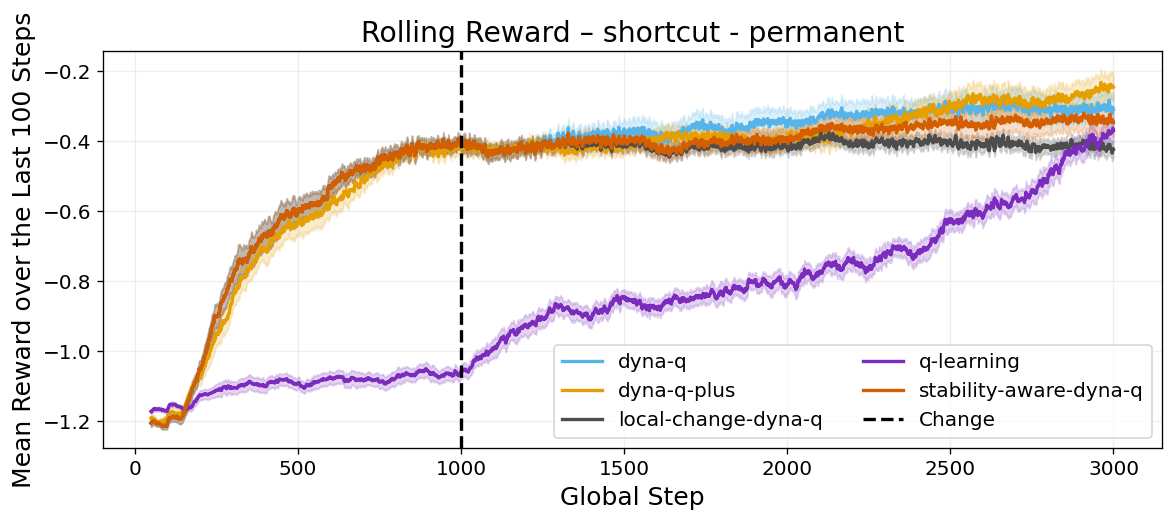

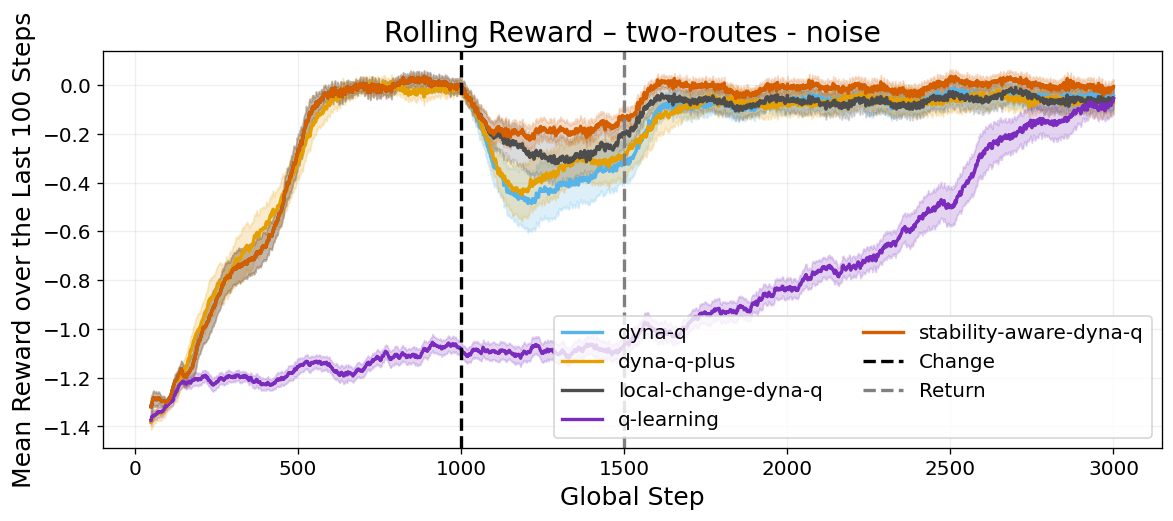

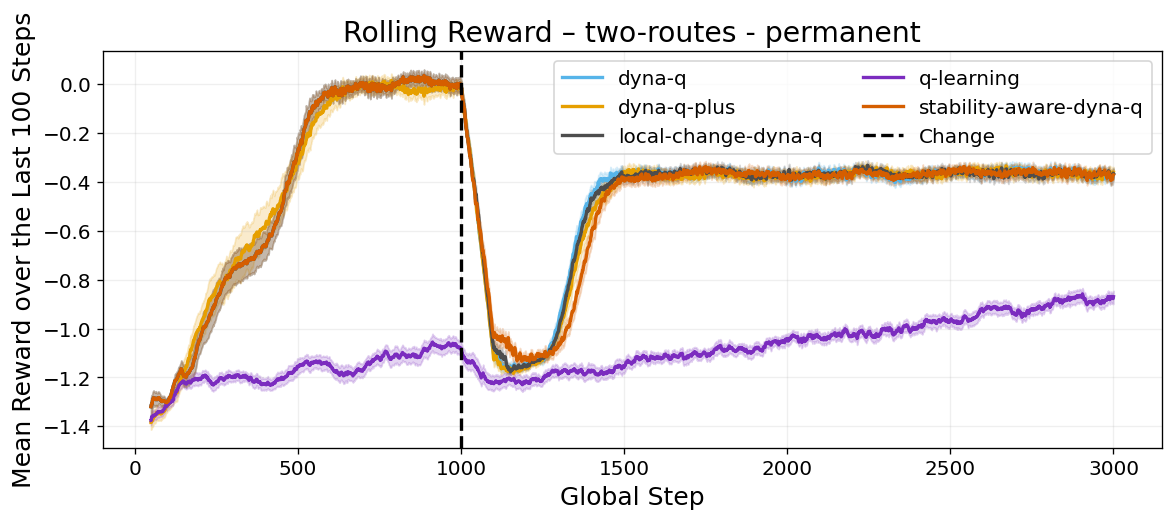

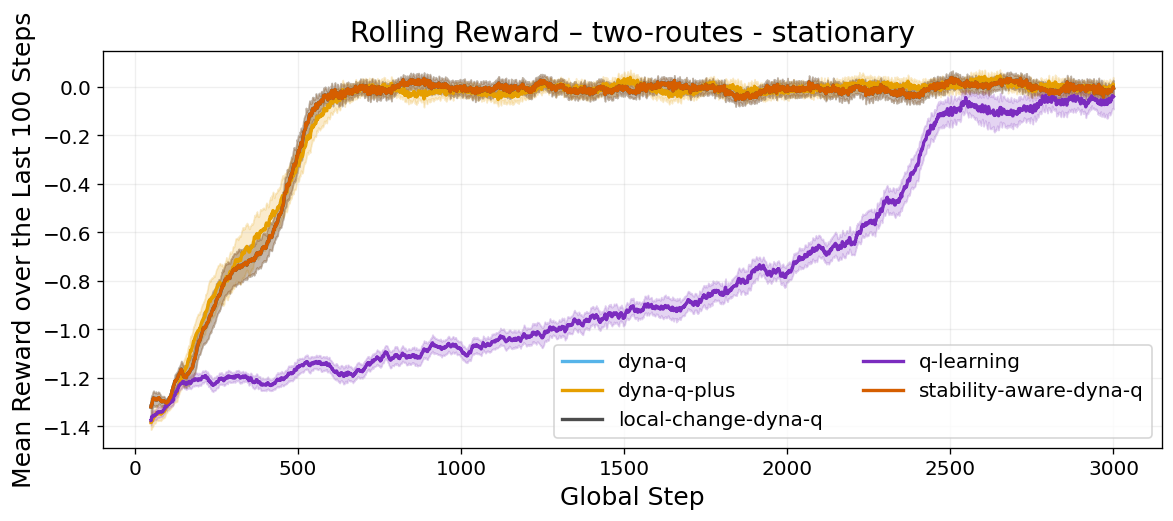

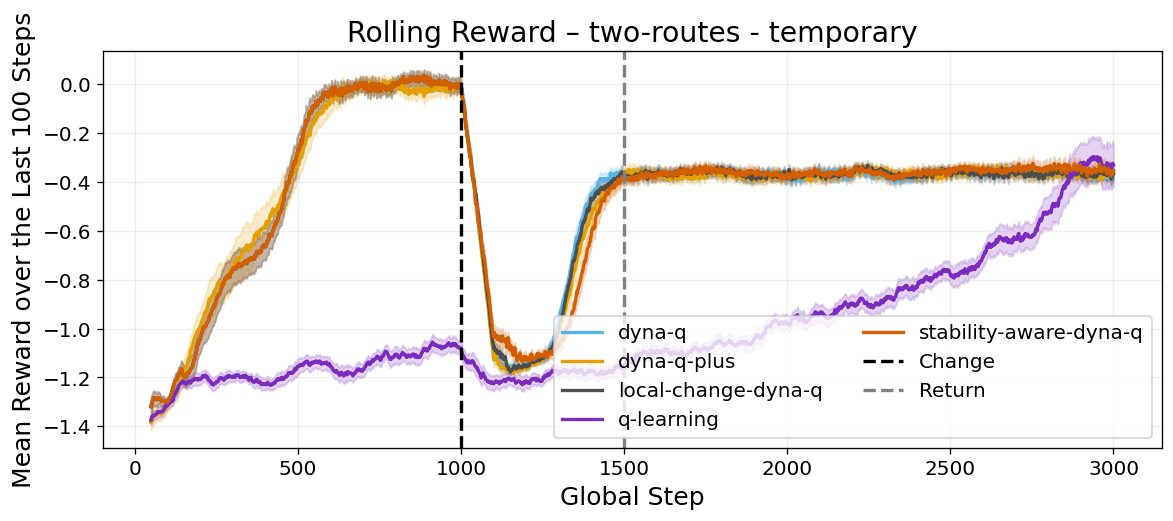

In [49]:
MAIN_COMPARISON_ALGORITHMS = [
    "dyna-q",
    "dyna-q-plus",
    "local-change-dyna-q",
    "q-learning",
    "stability-aware-dyna-q",
]
main_comparison_curve = step_curve.loc[
    step_curve["algorithm"].isin(MAIN_COMPARISON_ALGORITHMS)
]

for scenario, scenario_curve in main_comparison_curve.groupby("scenario"):
    figure, axis = plt.subplots(figsize=(10, 4.5))

    for algorithm in MAIN_COMPARISON_ALGORITHMS:
        algorithm_curve = scenario_curve.loc[
            scenario_curve["algorithm"].eq(algorithm)
        ]
        x = algorithm_curve["global_step"].to_numpy()
        mean = algorithm_curve["mean"].to_numpy()
        ci = algorithm_curve["ci"].to_numpy()
        color = ALGORITHM_COLORS[algorithm]
        linestyle = ALGORITHM_LINESTYLES.get(algorithm, "-")
        axis.plot(
            x, mean, color=color, linestyle=linestyle, label=algorithm
        )
        axis.fill_between(
            x, mean - ci, mean + ci, color=color, alpha=0.2
        )

    scenario_runs = runs.loc[
        (runs["scenario"] == scenario)
        & (runs["status"] == "done")
    ]
    change_step = scenario_runs["change_step"].iloc[0]
    if pd.notna(change_step):
        change_step = int(change_step)
        change_duration = scenario_runs["change_duration"].iloc[0]
        axis.axvline(
            change_step,
            color="black",
            linestyle="--",
            label="Change",
        )
        if pd.notna(change_duration):
            change_end = change_step + int(change_duration)
            axis.axvline(
                change_end,
                color="grey",
                linestyle="--",
                label="Return",
            )
    axis.set(
        title=f"Rolling Reward – {scenario}",
        xlabel="Global Step",
        ylabel=f"Mean Reward over the Last {ROLLING_WINDOW} Steps",
    )
    axis.legend(ncol=2)
    axis.grid(alpha=0.2)
    figure.tight_layout()
    plt.show()

<h1>Evidence Decay Ablation</h1>
This analysis isolates the effect of evidence decay by comparing Stability-Aware Dyna-Q across all tested decay values.

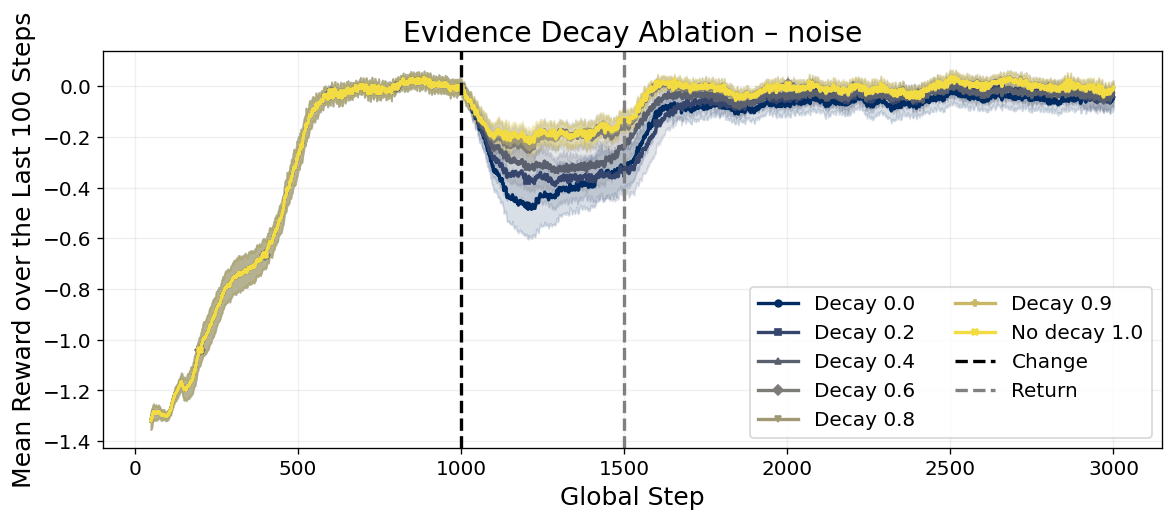

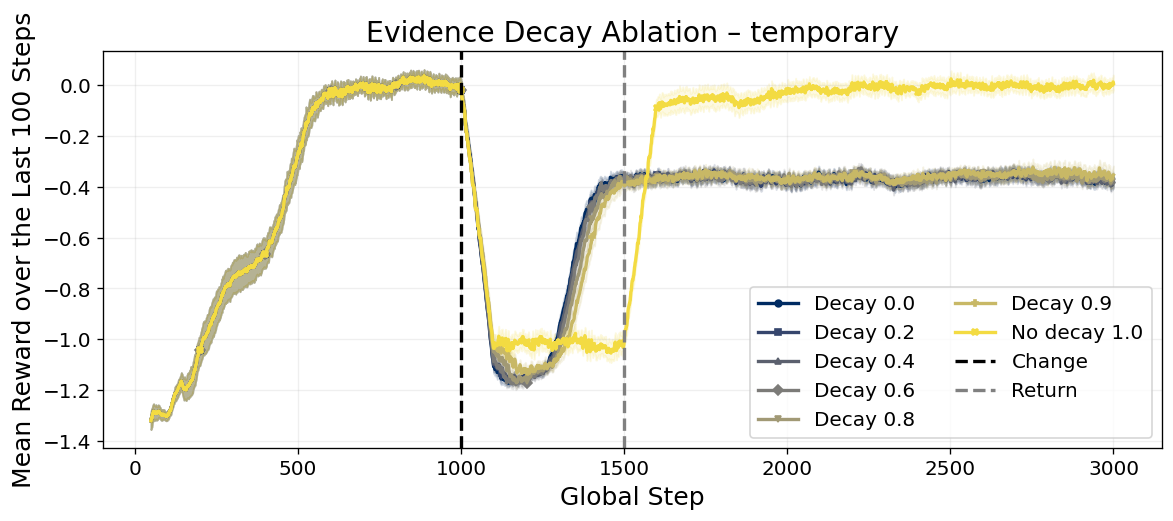

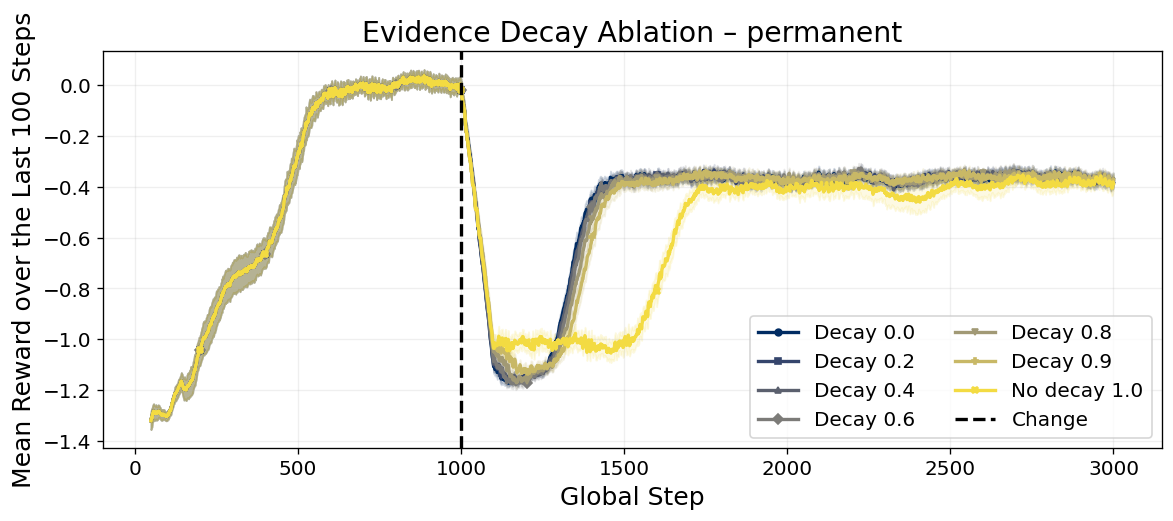

In [50]:
ABLATION_ALGORITHMS = list(STABILITY_AWARE_VARIANTS.values())
ABLATION_LABELS = {
    algorithm: (
        "No decay 1.0"
        if evidence_decay == 1.0
        else f"Decay {evidence_decay:.1f}"
    )
    for evidence_decay, algorithm in STABILITY_AWARE_VARIANTS.items()
}
ABLATION_COLORS = dict(
    zip(
        ABLATION_ALGORITHMS,
        plt.get_cmap("cividis")(
            np.linspace(0.05, 0.95, len(ABLATION_ALGORITHMS))
        ),
    )
)
ABLATION_MARKERS = dict(
    zip(ABLATION_ALGORITHMS, ["o", "s", "^", "D", "v", "P", "X"])
)
ABLATION_BEHAVIORS = ["noise", "temporary", "permanent"]

ablation_curve = step_curve.loc[
    step_curve["algorithm"].isin(ABLATION_ALGORITHMS)
]

for behavior in ABLATION_BEHAVIORS:
    figure, axis = plt.subplots(figsize=(10, 4.5))
    scenario = f"two-routes - {behavior}"

    scenario_curve = ablation_curve.loc[
        ablation_curve["scenario"].eq(scenario)
    ]

    for algorithm in ABLATION_ALGORITHMS:
        algorithm_curve = scenario_curve.loc[
            scenario_curve["algorithm"].eq(algorithm)
        ]

        x = algorithm_curve["global_step"].to_numpy()
        mean = algorithm_curve["mean"].to_numpy()
        ci = algorithm_curve["ci"].to_numpy()
        color = ABLATION_COLORS[algorithm]

        axis.plot(
            x,
            mean,
            color=color,
            linestyle="-",
            marker=ABLATION_MARKERS[algorithm],
            markevery=200,
            markersize=4,
            label=ABLATION_LABELS[algorithm],
        )
        axis.fill_between(
            x,
            mean - ci,
            mean + ci,
            color=color,
            alpha=0.15,
        )

    scenario_runs = runs.loc[
        runs["scenario"].eq(scenario),
        ["change_step", "change_duration"],
    ]

    change_step = int(scenario_runs["change_step"].iloc[0])
    axis.axvline(
        change_step,
        color="black",
        linestyle="--",
        label="Change",
    )

    change_duration = scenario_runs["change_duration"].iloc[0]
    if pd.notna(change_duration):
        axis.axvline(
            change_step + int(change_duration),
            color="grey",
            linestyle="--",
            label="Return",
        )

    axis.set(
        title=f"Evidence Decay Ablation – {behavior}",
        xlabel="Global Step",
        ylabel=(
            f"Mean Reward over the Last {ROLLING_WINDOW} Steps"
        ),
    )
    axis.legend(ncol=2)
    axis.grid(alpha=0.2)
    figure.tight_layout()
    plt.show()

<h1>Robustness During Transient Noise</h1>
The following metrics quantify reward loss, the strongest performance drop, recovery behavior, and variability during the noisy phase.

In [51]:
NOISE_START_STEP = 1000
NOISE_END_STEP = 1500
REFERENCE_START_STEP = 801
RECOVERY_TOLERANCE = 0.05
RECOVERY_STABILITY_STEPS = 100

noise_runs = steps.loc[
    (steps["environment"] == "two-routes")
    & steps["world_behavior"].eq("noise")
    & steps["change_duration"].eq(500)
]

noise_phase = noise_runs.loc[
    (noise_runs["global_step"] > NOISE_START_STEP)
    & (noise_runs["global_step"] <= NOISE_END_STEP)
]

variance_per_step = (
    noise_phase.groupby(["algorithm", "global_step"])
    ["rolling_reward"]
    .agg(
        mean_reward="mean",
        reward_variance="var",
        reward_std="std",
        seeds="count",
    )
    .reset_index()
)

variability_summary = (
    variance_per_step.groupby("algorithm")
    .agg(
        average_variance=("reward_variance", "mean"),
        average_std=("reward_std", "mean"),
        worst_std=("reward_std", "max"),
    )
)

metric_records = []

for experiment_id, run_steps in noise_runs.groupby("experiment_id"):
    run_steps = run_steps.sort_values("global_step")
    reference_steps = run_steps.loc[
        run_steps["global_step"].between(
            REFERENCE_START_STEP,
            NOISE_START_STEP,
        )
    ]
    noise_steps = run_steps.loc[
        (run_steps["global_step"] > NOISE_START_STEP)
        & (run_steps["global_step"] <= NOISE_END_STEP)
    ]
    recovery_steps = run_steps.loc[
        run_steps["global_step"] > NOISE_END_STEP
    ]

    baseline_reward = reference_steps["reward"].mean()
    baseline_rolling_reward = reference_steps["rolling_reward"].mean()
    recovery_threshold = (
        baseline_rolling_reward - RECOVERY_TOLERANCE
    )
    stable_recovery = (
        recovery_steps["rolling_reward"].ge(recovery_threshold)
        .rolling(
            RECOVERY_STABILITY_STEPS,
            min_periods=RECOVERY_STABILITY_STEPS,
        )
        .sum()
        .eq(RECOVERY_STABILITY_STEPS)
    )
    stable_window_ends = np.flatnonzero(stable_recovery.to_numpy())

    recovered = stable_window_ends.size > 0
    recovery_duration = np.nan
    if recovered:
        recovery_start_index = (
            stable_window_ends[0] - RECOVERY_STABILITY_STEPS + 1
        )
        recovery_start_step = recovery_steps.iloc[recovery_start_index][
            "global_step"
        ]
        recovery_duration = recovery_start_step - NOISE_END_STEP

    first_step = run_steps.iloc[0]
    metric_records.append(
        {
            "algorithm": first_step["algorithm"],
            "seed": first_step["seed"],
            "average_reward": noise_steps["reward"].mean(),
            "cumulative_reward_loss": (
                baseline_reward * len(noise_steps)
                - noise_steps["reward"].sum()
            ),
            "strongest_drop": max(
                0.0,
                baseline_rolling_reward
                - noise_steps["rolling_reward"].min(),
            ),
            "recovery_steps": recovery_duration,
            "recovered": recovered,
        }
    )

per_seed_metrics = pd.DataFrame(metric_records)
metric_summary = per_seed_metrics.groupby("algorithm").agg(
    average_reward=("average_reward", "mean"),
    average_cumulative_reward_loss=("cumulative_reward_loss", "mean"),
    average_strongest_drop=("strongest_drop", "mean"),
    average_recovery_steps=("recovery_steps", "mean"),
    recovery_rate=("recovered", "mean"),
    seeds=("seed", "nunique"),
)

stability_summary = metric_summary.join(variability_summary).sort_values(
    "average_reward",
    ascending=False,
)

display(stability_summary)

,average_reward,average_cumulative_reward_loss,average_strongest_drop,average_recovery_steps,recovery_rate,seeds,average_variance,average_std,worst_std
algorithm,,,,,,,,,
stability-aware-dyna-q,-0.18420,94.00,0.501221,242.900000,0.80,50,0.022539,0.149334,0.186087
stability-aware-dyna-q (no decay),-0.18420,94.00,0.501221,242.900000,0.80,50,0.022539,0.149334,0.186087
stability-aware-dyna-q (decay 0.8),-0.19176,97.78,0.522021,242.225000,0.80,50,0.027344,0.163426,0.222557
stability-aware-dyna-q (decay 0.6),-0.20040,102.10,0.558421,242.550000,0.80,50,0.034012,0.181696,0.240696
local-change-dyna-q,-0.25632,130.06,0.585421,245.000000,0.66,50,0.070149,0.256442,0.352982
stability-aware-dyna-q (decay 0.4),-0.28792,145.86,0.740821,275.833333,0.72,50,0.077119,0.270507,0.334523
dyna-q-plus,-0.33892,161.66,0.765089,271.756757,0.74,50,0.095748,0.297714,0.399947
stability-aware-dyna-q (decay 0.2),-0.34768,175.74,0.814021,287.628571,0.70,50,0.095770,0.300797,0.387909
dyna-q,-0.38276,193.28,0.900421,293.666667,0.66,50,0.113818,0.325722,0.438740


## Behavior of the Stability Mechanism

The following plots compare the Stability-Aware variants with and without evidence decay. They focus on the transition before the hazard: state `(1, 4)` with action `right`. Model stability is the largest normalized evidence weight and indicates how clearly one transition dominates. The stability of the observed transition is also its weight in the real Q-value update. Values are updated only when the agent executes this transition. The internal state is carried forward between visits. The black line marks the start of the change, and the gray line marks the end of the noise or temporary phase.

In [40]:
MECHANISM_ALGORITHMS = [
    "stability-aware-dyna-q",
    DECAY_08_ALGORITHM,
    NO_DECAY_ALGORITHM,
]
MECHANISM_ALGORITHM_LABELS = {
    "stability-aware-dyna-q": "Decay 0.9",
    DECAY_08_ALGORITHM: "Decay 0.8",
    NO_DECAY_ALGORITHM: "No decay 1.0",
}
MECHANISM_ENVIRONMENT = "two-routes"
MECHANISM_STATE = (1, 4)
MECHANISM_ACTION = "right"
MECHANISM_BEHAVIORS = [
    "stationary",
    "noise",
    "temporary",
    "permanent",
]
MISMATCH_WINDOW = 100
MECHANISM_METRICS = [
    "stability_score",
    "observed_transition_stability",
    "candidate_count",
]

mechanism_observations = steps.loc[
    steps["algorithm"].isin(MECHANISM_ALGORITHMS)
    & steps["environment"].eq(MECHANISM_ENVIRONMENT)
    & steps["world_behavior"].isin(MECHANISM_BEHAVIORS)
    & steps["state_row"].eq(MECHANISM_STATE[0])
    & steps["state_column"].eq(MECHANISM_STATE[1])
    & steps["action"].eq(MECHANISM_ACTION)
].copy()

mechanism_timelines = []

for experiment_id, observations in mechanism_observations.groupby(
    "experiment_id"
):
    observations = observations.sort_values("global_step")
    last_global_step = int(
        steps.loc[
            steps["experiment_id"].eq(experiment_id),
            "global_step",
        ].max()
    )
    global_steps = pd.RangeIndex(
        1,
        last_global_step + 1,
        name="global_step",
    )
    timeline = (
        observations.set_index("global_step")[MECHANISM_METRICS]
        .reindex(global_steps)
        .ffill()
        .reset_index()
    )

    mismatch_events = pd.Series(0.0, index=global_steps)
    mismatch_steps = observations.loc[
        observations["model_mismatch"].eq(1),
        "global_step",
    ]
    mismatch_events.loc[mismatch_steps] = 1.0

    run = observations.iloc[0]
    timeline["experiment_id"] = experiment_id
    timeline["algorithm"] = run["algorithm"]
    timeline["seed"] = run["seed"]
    timeline["world_behavior"] = run["world_behavior"]
    timeline["mismatch_event"] = mismatch_events.to_numpy()
    timeline["mismatches_in_window"] = (
        mismatch_events.rolling(MISMATCH_WINDOW, min_periods=1)
        .sum()
        .to_numpy()
    )
    mechanism_timelines.append(timeline)

mechanism_timeline = pd.concat(
    mechanism_timelines,
    ignore_index=True,
)

display(
    mechanism_observations.groupby(["algorithm", "world_behavior"])
    .agg(
        seeds=("seed", "nunique"),
        transition_visits=("global_step", "size"),
        mismatches=("model_mismatch", "sum"),
    )
)

seeds  transition_visits  \
algorithm                          world_behavior                             
stability-aware-dyna-q             noise              50              13762   
                                   permanent          50               3997   
                                   stationary         50              13787   
                                   temporary          50               4105   
stability-aware-dyna-q (decay 0.8) noise              50              13740   
                                   permanent          50               3662   
                                   stationary         50              13787   
                                   temporary          50               3666   
stability-aware-dyna-q (no decay)  noise              50              13764   
                                   permanent          50               6689   
                                   stationary         50              13787   
                                   temporary          50              13288   

                                                   mismatches  
algorithm                          world_behavior              
stability-aware-dyna-q             noise                468.0  
                                   permanent            350.0  
                                   stationary             0.0  
                                   temporary            381.0  
stability-aware-dyna-q (decay 0.8) noise                496.0  
                                   permanent            200.0  
                                   stationary             0.0  
                                   temporary            210.0  
stability-aware-dyna-q (no decay)  noise                468.0  
                                   permanent           3242.0  
                                   stationary             0.0  
                                   temporary           2572.0

<h1>Evolution of the Internal Stability Model</h1>
These plots show how model stability, observed transition stability, and the number of transition candidates evolve for the affected state-action pair.

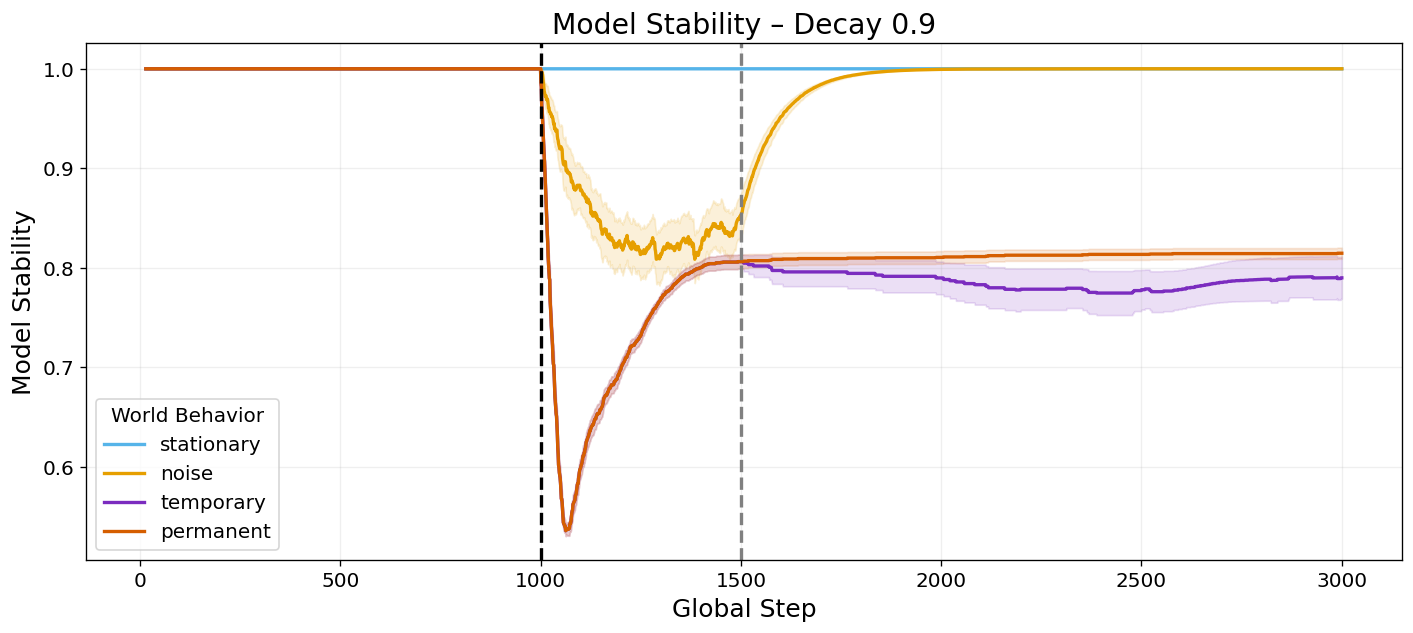

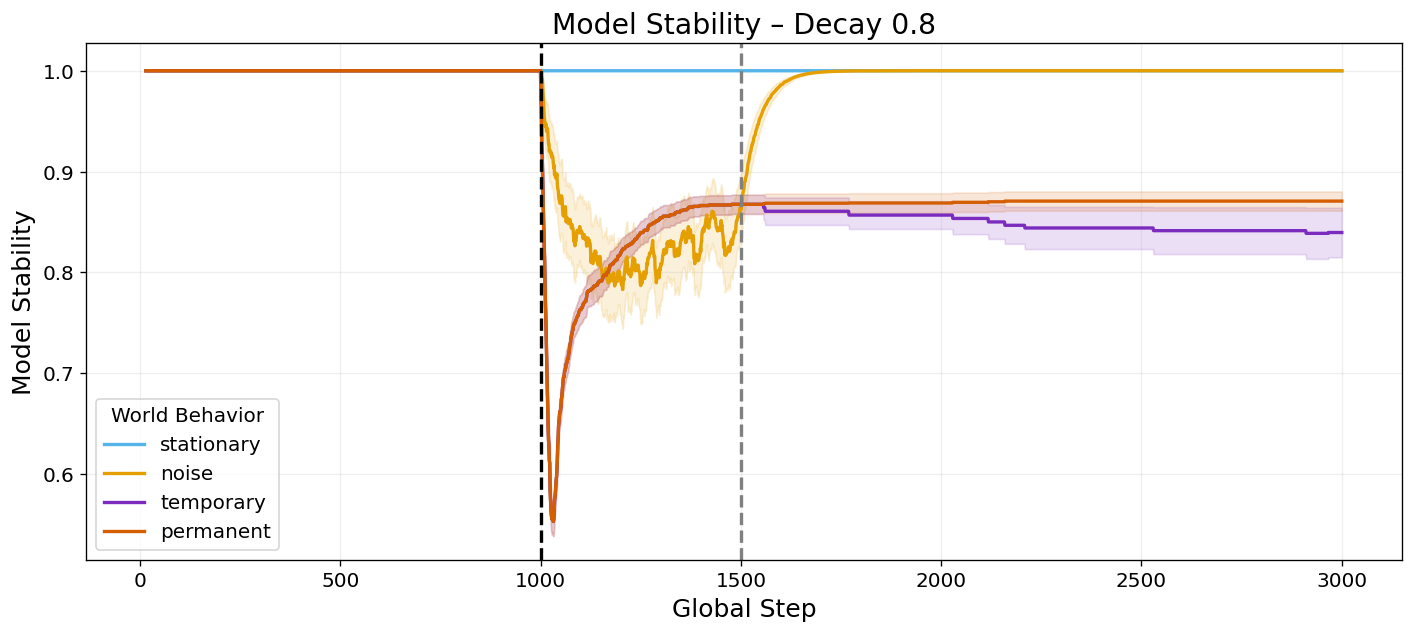

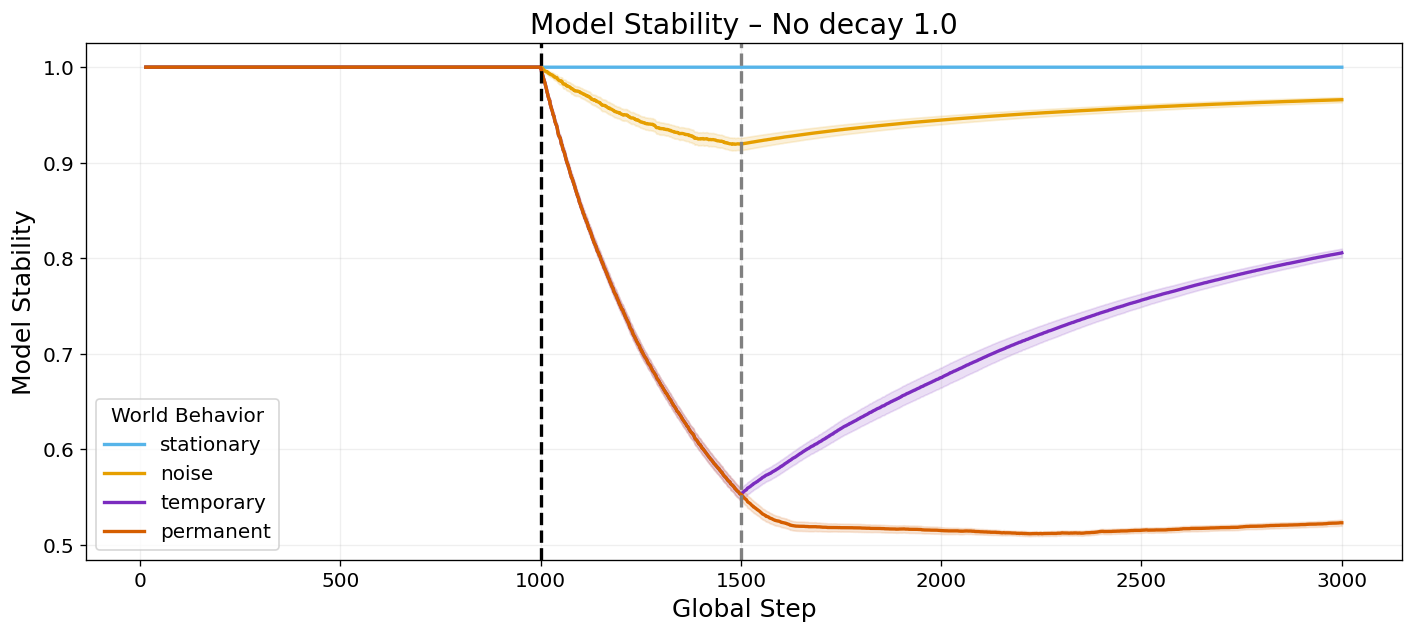

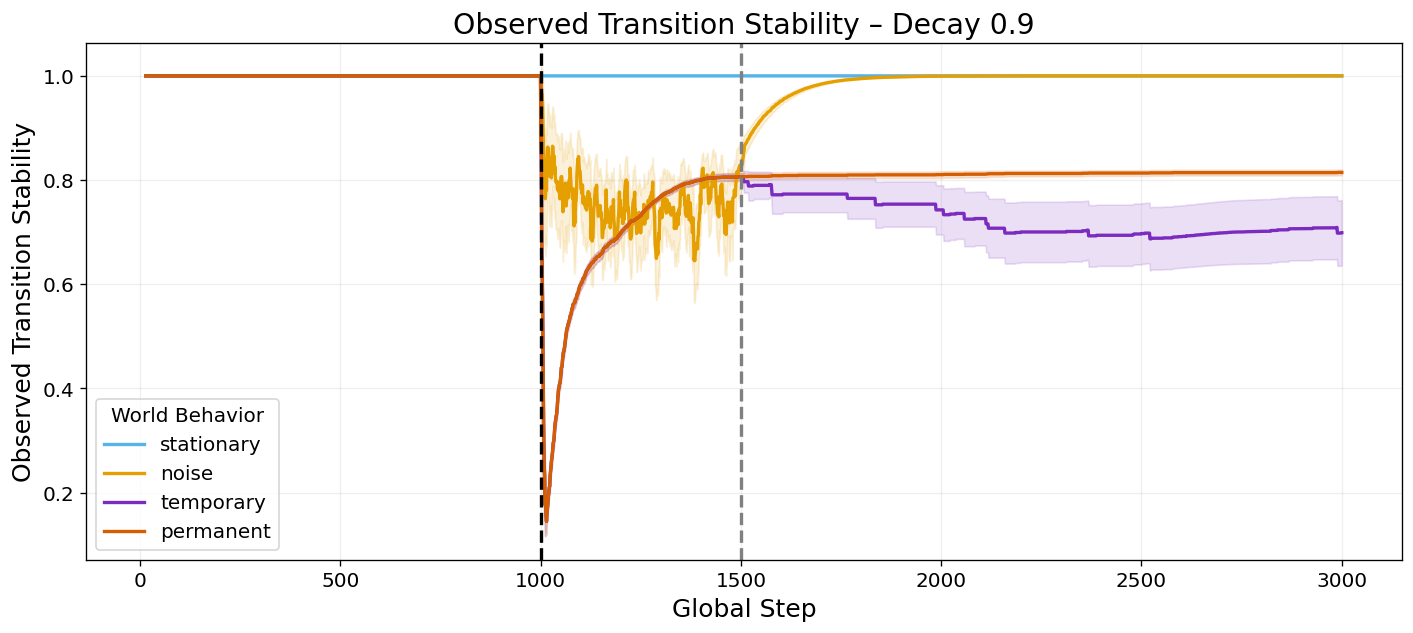

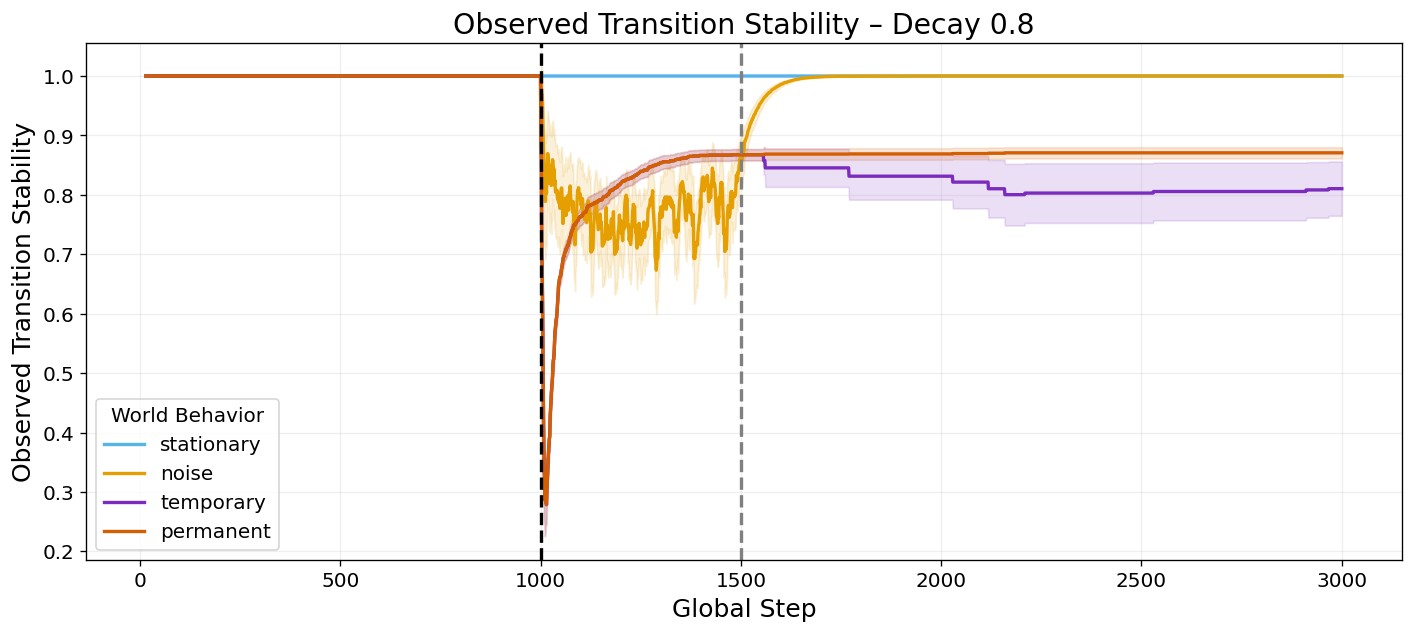

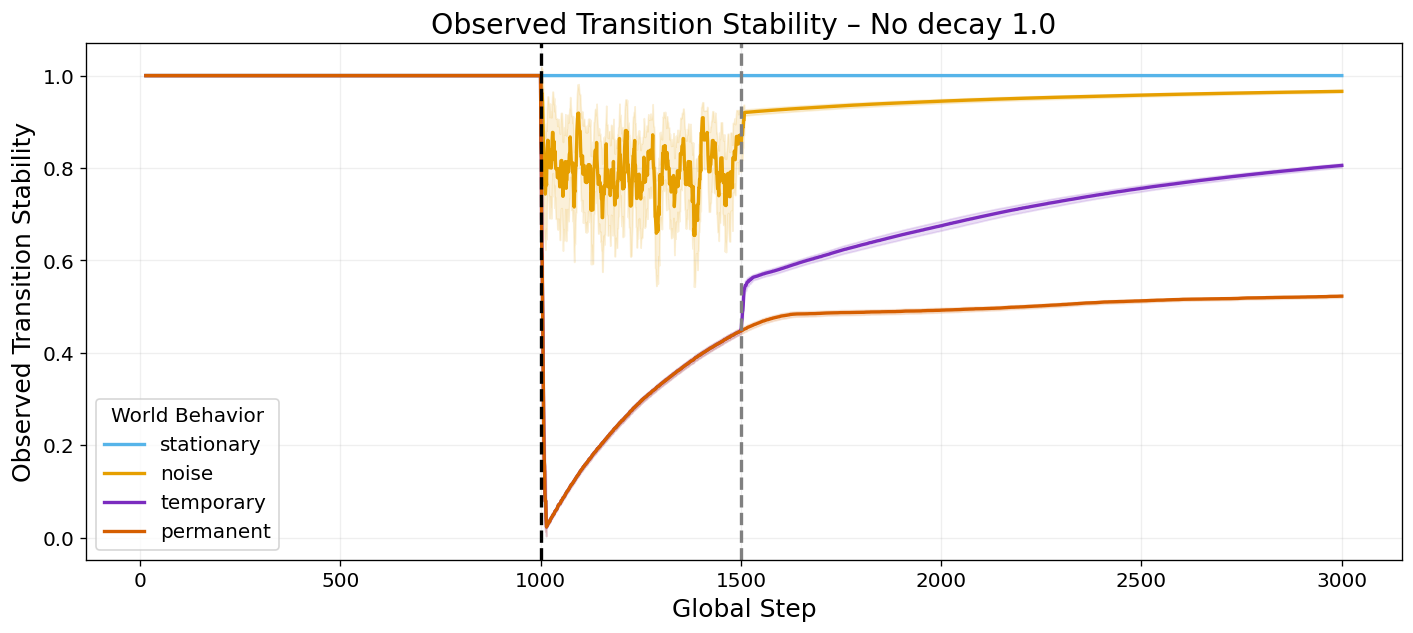

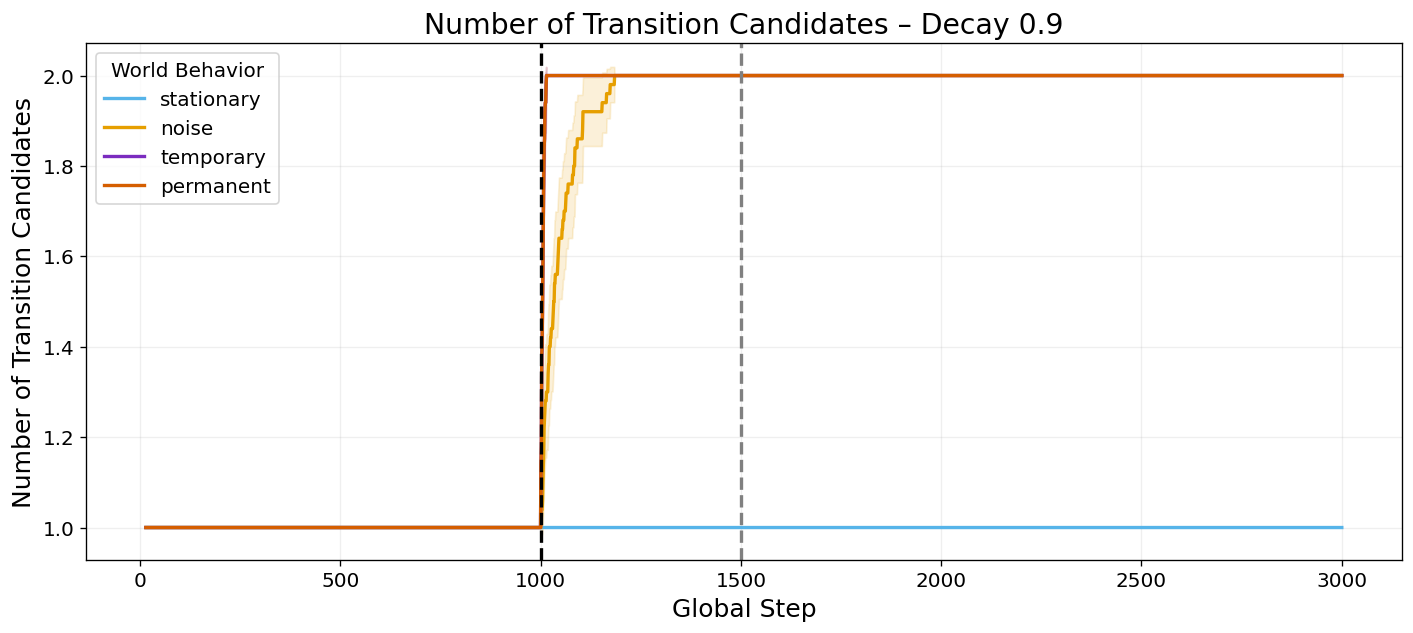

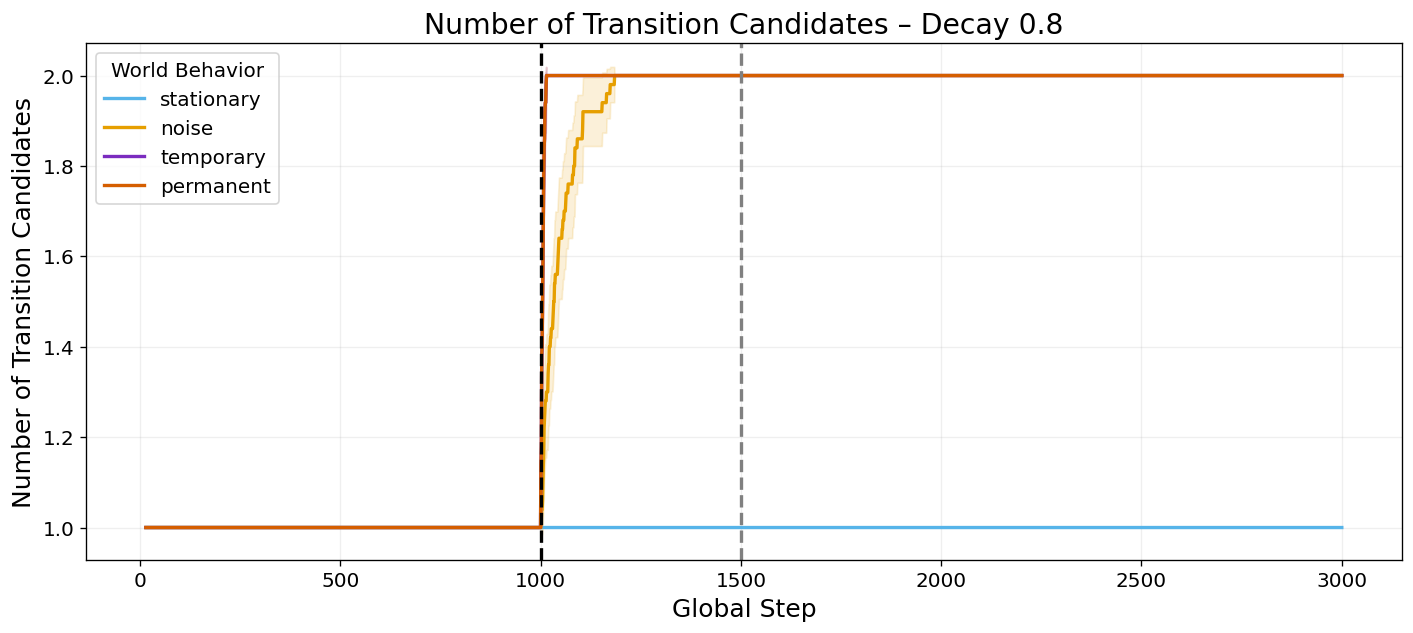

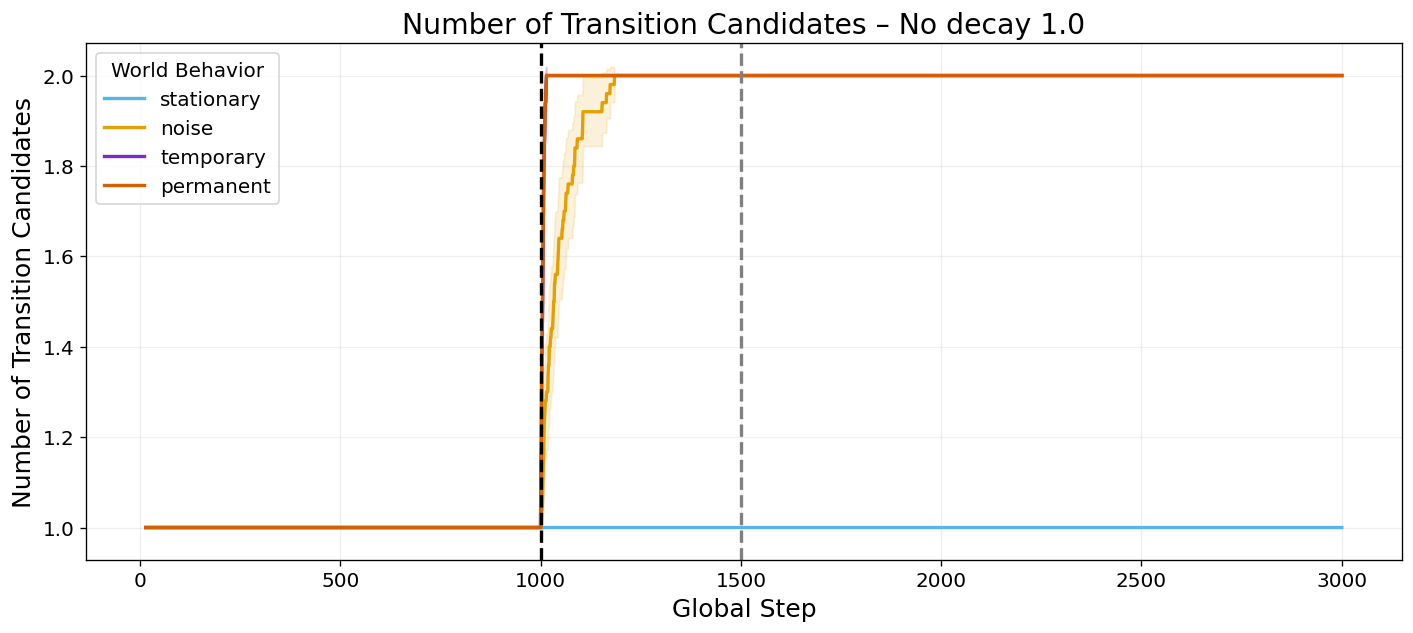

In [52]:
metric_labels = {
    "stability_score": "Model Stability",
    "observed_transition_stability": (
        "Observed Transition Stability"
    ),
    "candidate_count": "Number of Transition Candidates",
}

for metric in MECHANISM_METRICS:
    metric_curve = (
        mechanism_timeline.groupby(
            ["algorithm", "world_behavior", "global_step"]
        )[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    metric_curve["ci"] = (
        CONFIDENCE_Z
        * metric_curve["std"].fillna(0.0)
        / np.sqrt(metric_curve["count"])
    )

    for algorithm in MECHANISM_ALGORITHMS:
        figure, axis = plt.subplots(figsize=(12, 5.5))
        algorithm_curve = metric_curve.loc[
            metric_curve["algorithm"].eq(algorithm)
        ]

        for behavior in MECHANISM_BEHAVIORS:
            curve = algorithm_curve.loc[
                algorithm_curve["world_behavior"].eq(behavior)
            ]
            x = curve["global_step"].to_numpy()
            mean = curve["mean"].to_numpy()
            ci = curve["ci"].to_numpy()
            color = BEHAVIOR_COLORS[behavior]
            axis.plot(x, mean, color=color, label=behavior)
            axis.fill_between(
                x, mean - ci, mean + ci, color=color, alpha=0.15
            )

        axis.axvline(1000, color="black", linestyle="--")
        axis.axvline(1500, color="grey", linestyle="--")
        axis.grid(alpha=0.2)

        axis.set(
            title=(
                f"{metric_labels[metric]} – "
                f"{MECHANISM_ALGORITHM_LABELS[algorithm]}"
            ),
            xlabel="Global Step",
            ylabel=metric_labels[metric],
        )
        axis.legend(title="World Behavior")
        figure.tight_layout()
        plt.show()

<h1>Detected Transition Mismatches</h1>
The rolling mismatch count shows how strongly each evidence-decay variant reacts to unexpected transitions in the different world behaviors.

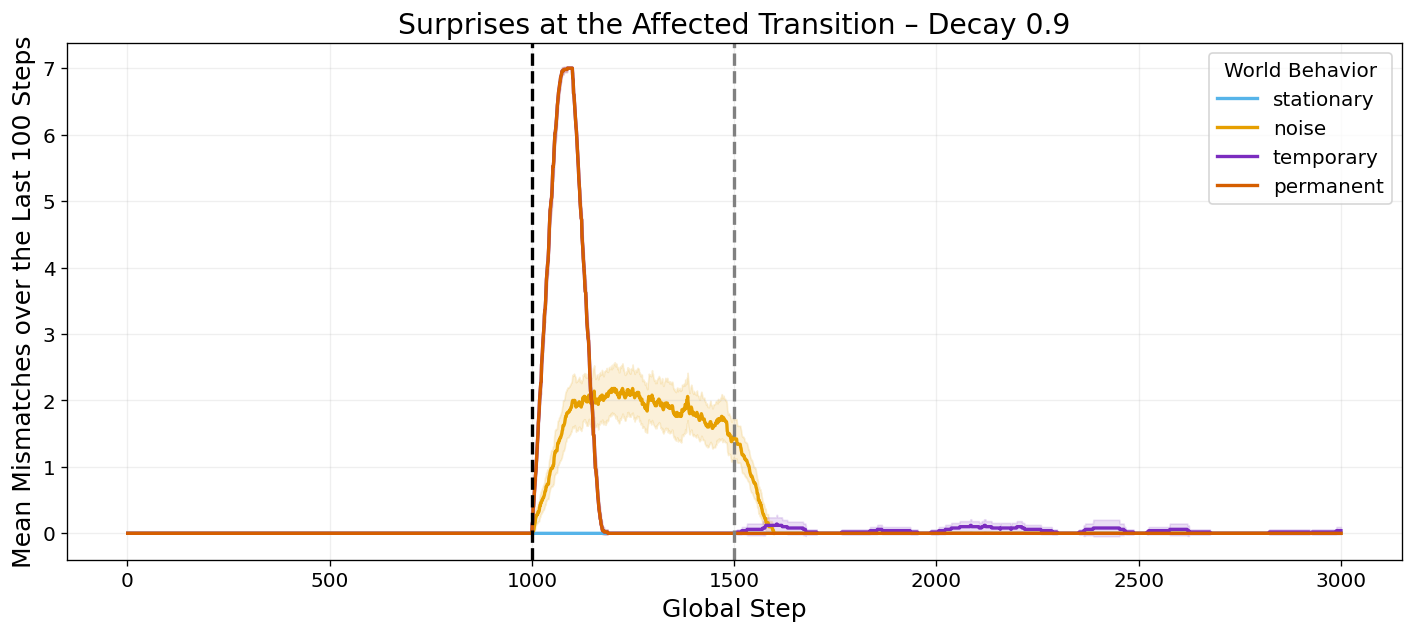

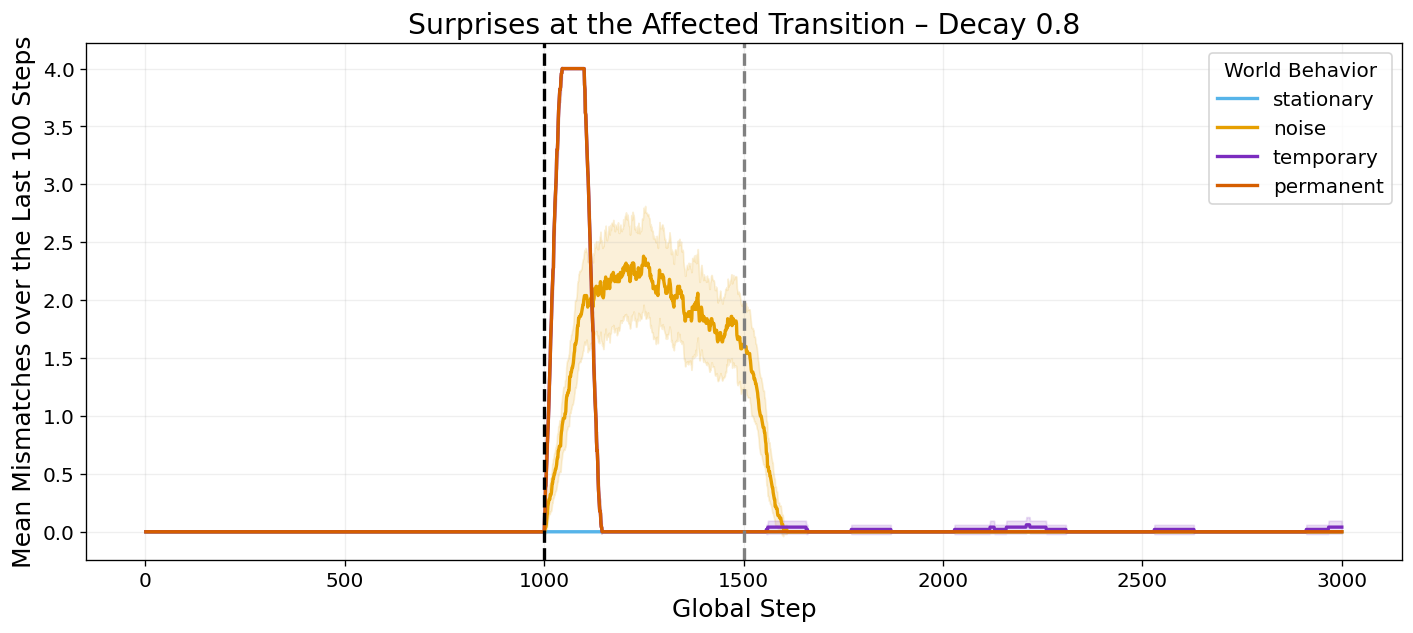

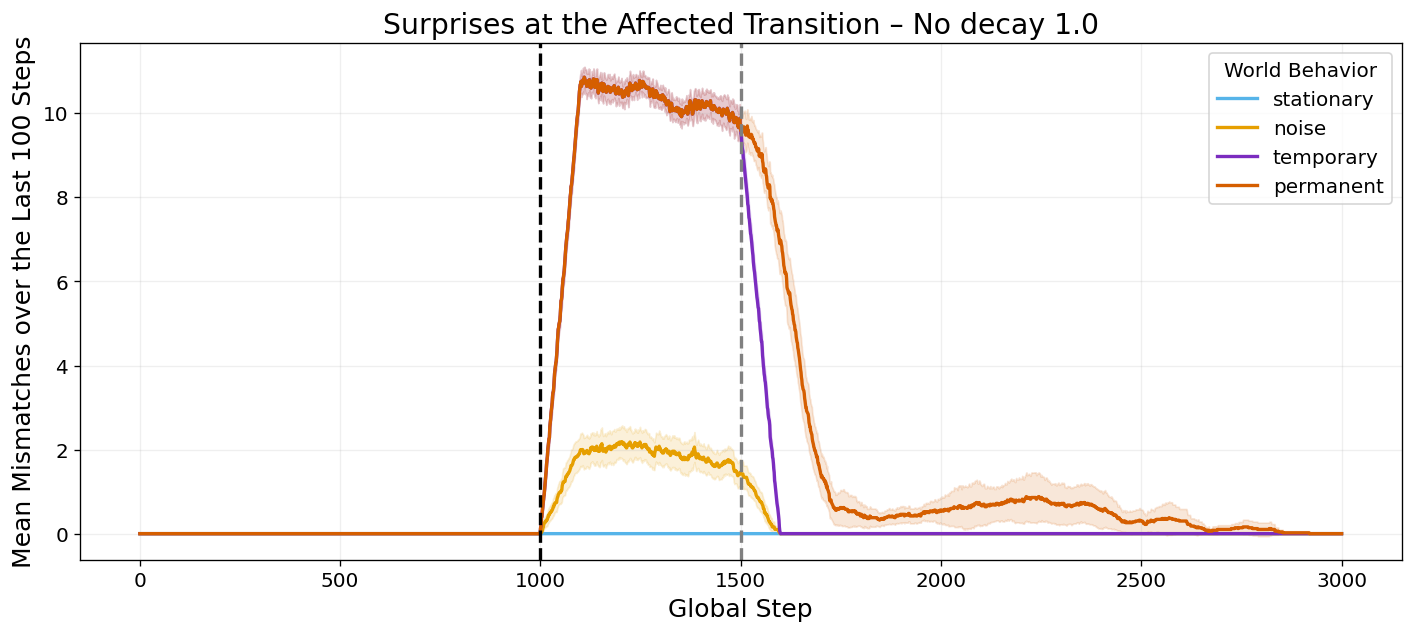

In [53]:
mismatch_curve = (
    mechanism_timeline.groupby(
        ["algorithm", "world_behavior", "global_step"]
    )["mismatches_in_window"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
mismatch_curve["ci"] = (
    CONFIDENCE_Z
    * mismatch_curve["std"].fillna(0.0)
    / np.sqrt(mismatch_curve["count"])
)

for algorithm in MECHANISM_ALGORITHMS:
    figure, axis = plt.subplots(figsize=(12, 5.5))
    algorithm_curve = mismatch_curve.loc[
        mismatch_curve["algorithm"].eq(algorithm)
    ]

    for behavior in MECHANISM_BEHAVIORS:
        curve = algorithm_curve.loc[
            algorithm_curve["world_behavior"].eq(behavior)
        ]
        x = curve["global_step"].to_numpy()
        mean = curve["mean"].to_numpy()
        ci = curve["ci"].to_numpy()
        color = BEHAVIOR_COLORS[behavior]
        axis.plot(x, mean, color=color, label=behavior)
        axis.fill_between(
            x, mean - ci, mean + ci, color=color, alpha=0.15
        )

    axis.axvline(1000, color="black", linestyle="--")
    axis.axvline(1500, color="grey", linestyle="--")
    axis.set(
        title=(
            "Surprises at the Affected Transition – "
            f"{MECHANISM_ALGORITHM_LABELS[algorithm]}"
        ),
        xlabel="Global Step",
        ylabel=(
            f"Mean Mismatches over the Last "
            f"{MISMATCH_WINDOW} Steps"
        ),
    )
    axis.grid(alpha=0.2)
    axis.legend(title="World Behavior")
    figure.tight_layout()
    plt.show()

<h1>Mechanism Comparison During the Change</h1>
The boxplots summarize stability and mismatch behavior per seed between steps 1001 and 1500, making the effect of evidence decay directly comparable.

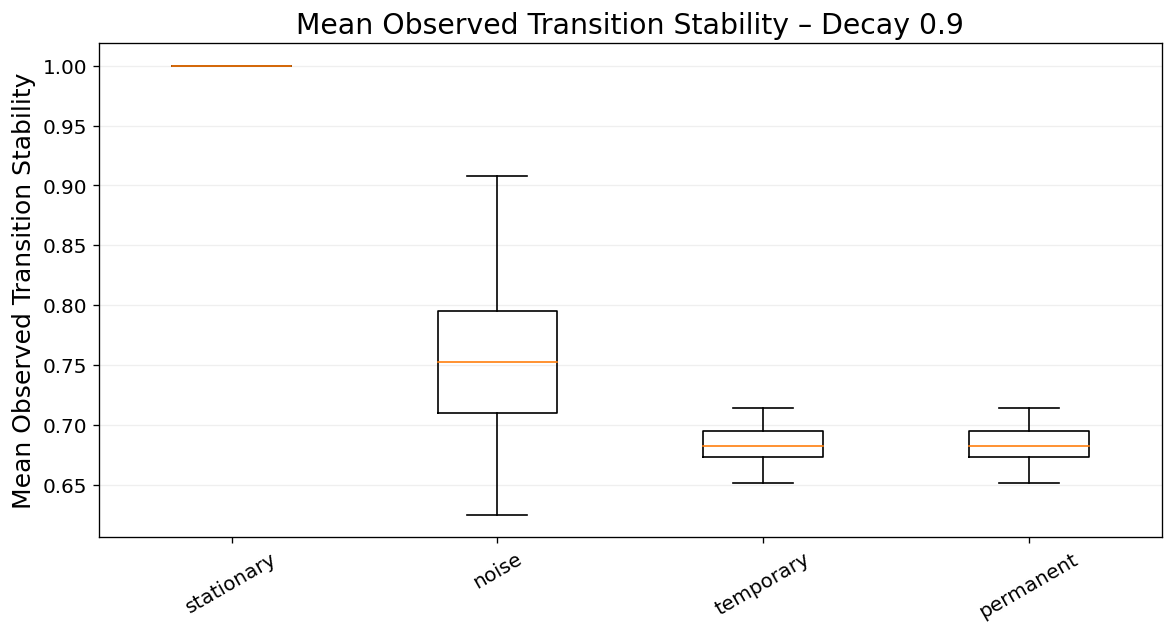

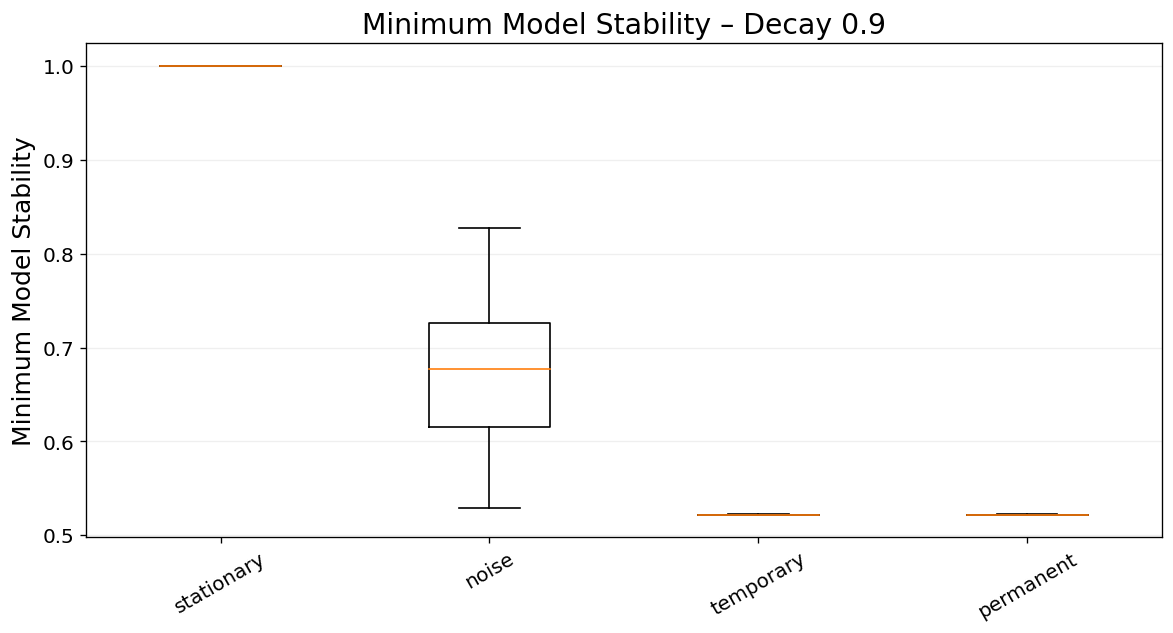

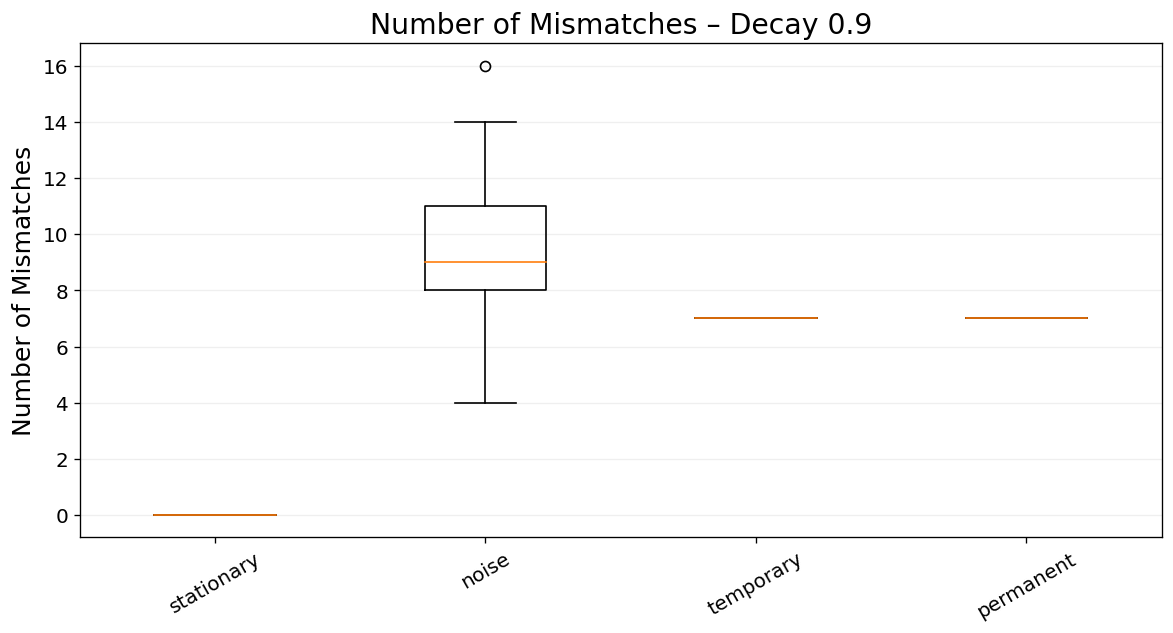

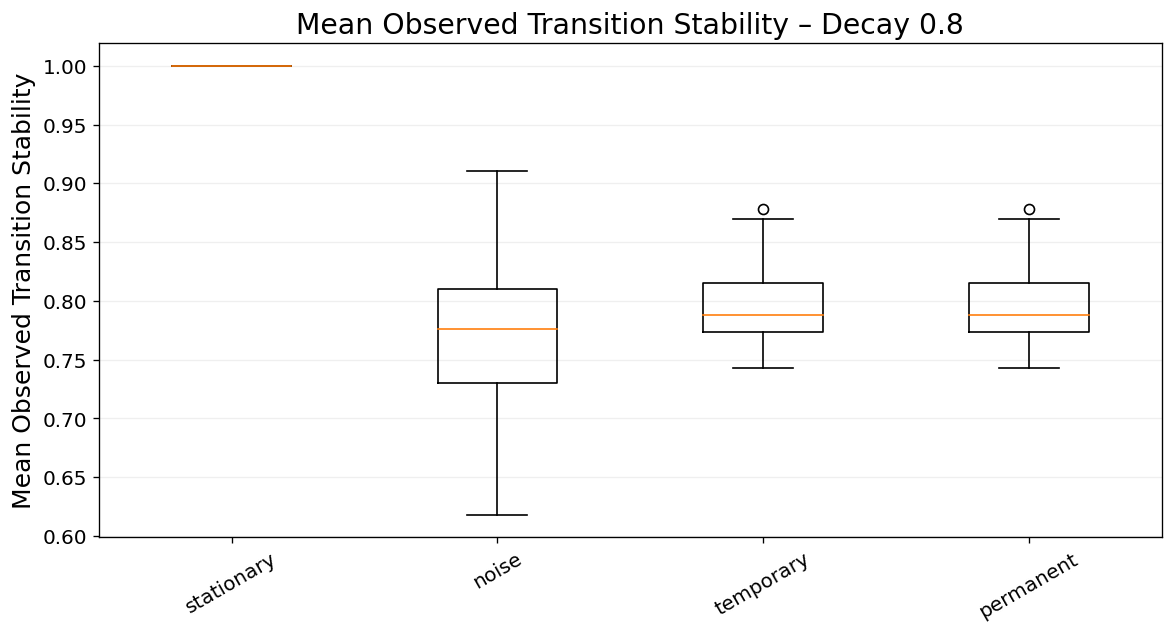

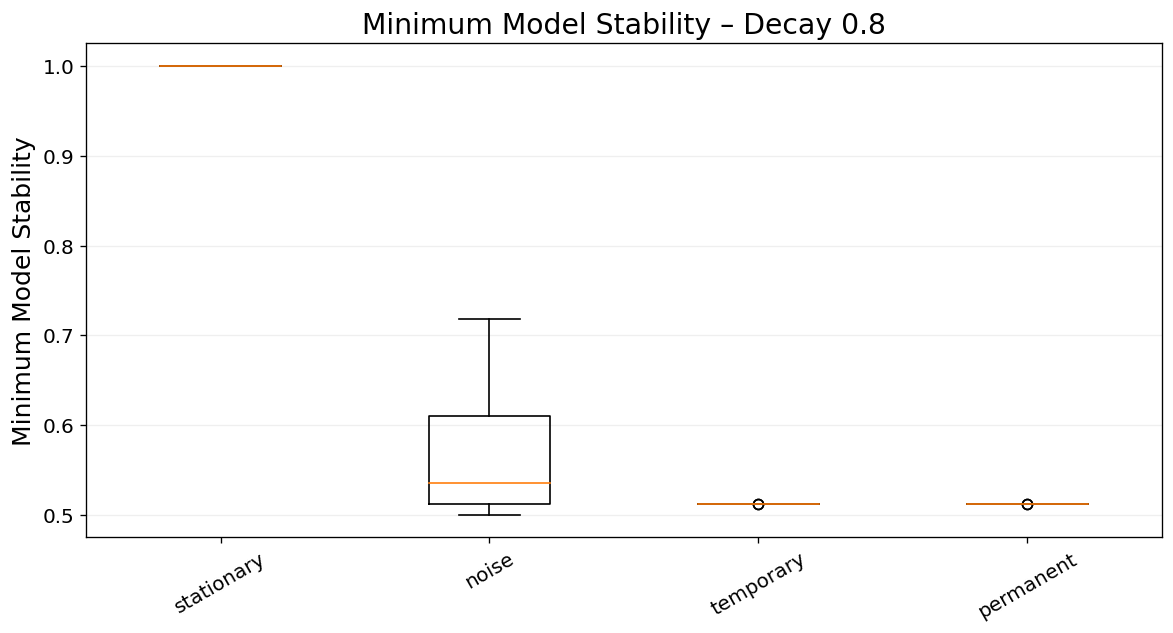

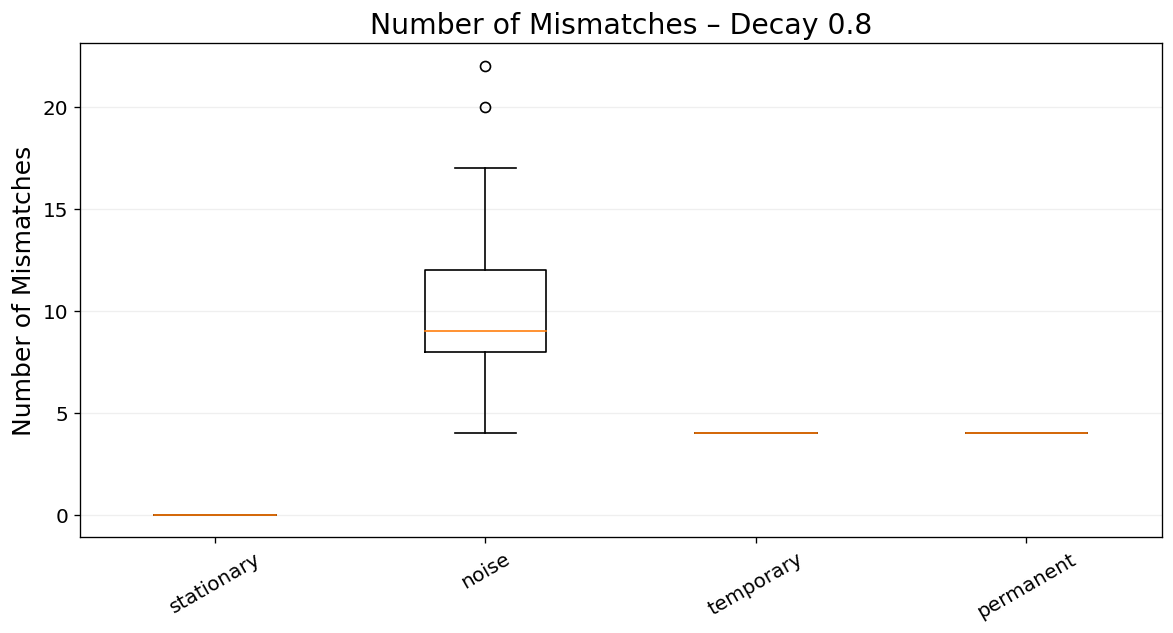

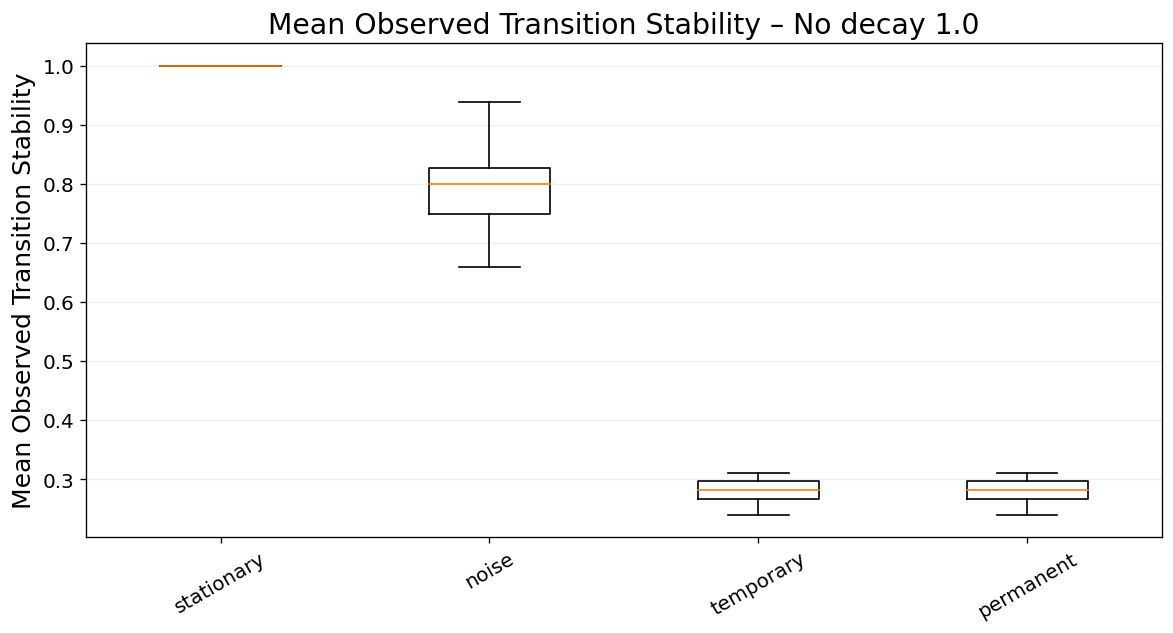

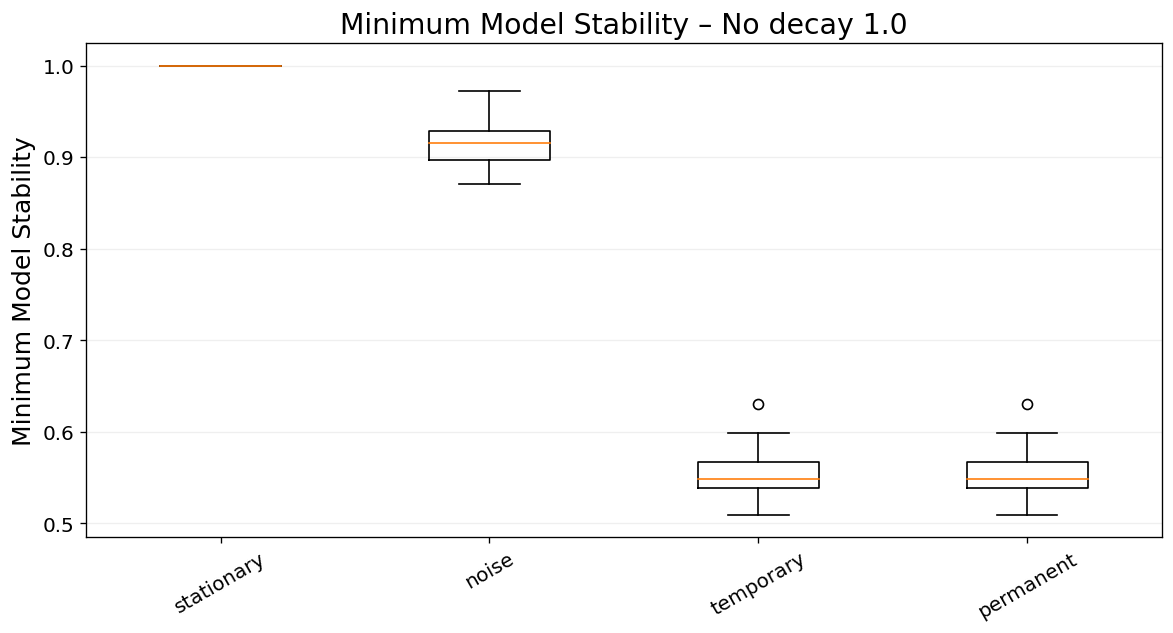

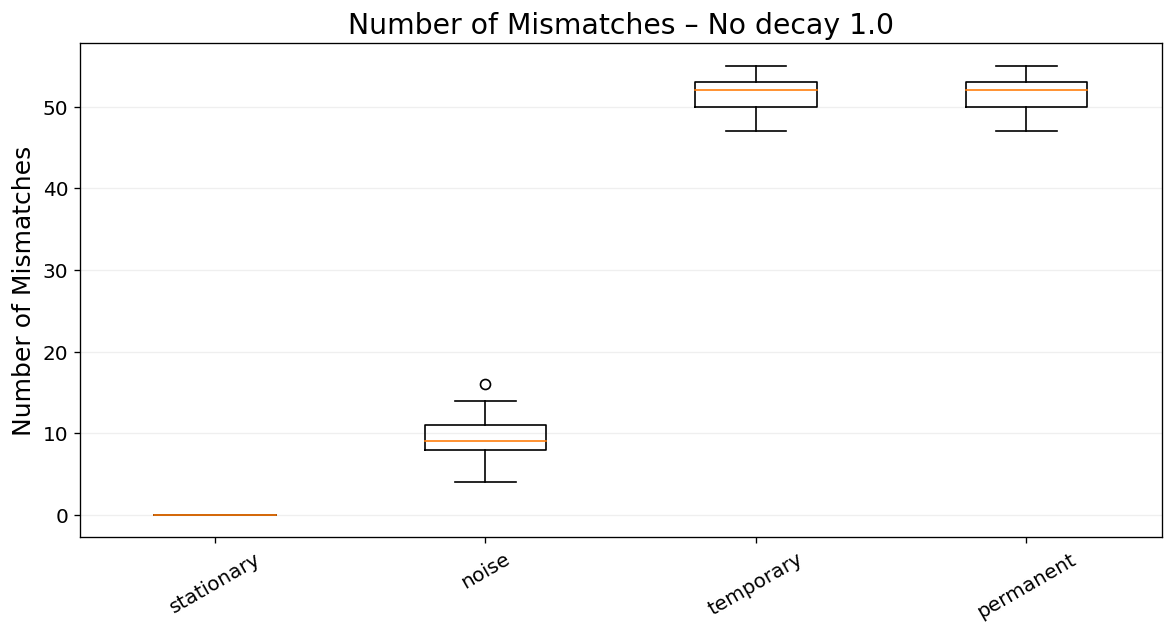

average_observed_stability  \
algorithm                          world_behavior                               
stability-aware-dyna-q             noise                             0.757168   
                                   permanent                         0.683161   
                                   stationary                        1.000000   
                                   temporary                         0.683161   
stability-aware-dyna-q (decay 0.8) noise                             0.775079   
                                   permanent                         0.794928   
                                   stationary                        1.000000   
                                   temporary                         0.794928   
stability-aware-dyna-q (no decay)  noise                             0.795207   
                                   permanent                         0.281495   
                                   stationary                        1.000000   
                                   temporary                         0.281495   

                                                   minimum_model_stability  \
algorithm                          world_behavior                            
stability-aware-dyna-q             noise                          0.673837   
                                   permanent                      0.522062   
                                   stationary                     1.000000   
                                   temporary                      0.522062   
stability-aware-dyna-q (decay 0.8) noise                          0.560325   
                                   permanent                      0.512000   
                                   stationary                     1.000000   
                                   temporary                      0.512000   
stability-aware-dyna-q (no decay)  noise                          0.914815   
                                   permanent                      0.552836   
                                   stationary                     1.000000   
                                   temporary                      0.552836   

                                                   average_mismatches  seeds  
algorithm                          world_behavior                             
stability-aware-dyna-q             noise                         9.36     50  
                                   permanent                     7.00     50  
                                   stationary                    0.00     50  
                                   temporary                     7.00     50  
stability-aware-dyna-q (decay 0.8) noise                         9.90     50  
                                   permanent                     4.00     50  
                                   stationary                    0.00     50  
                                   temporary                     4.00     50  
stability-aware-dyna-q (no decay)  noise                         9.36     50  
                                   permanent                    51.44     50  
                                   stationary                    0.00     50  
                                   temporary                    51.44     50

In [54]:
comparison_window = mechanism_timeline.loc[
    mechanism_timeline["global_step"].between(1001, 1500)
]
mechanism_per_seed = (
    comparison_window.groupby(
        ["experiment_id", "algorithm", "world_behavior", "seed"],
        as_index=False,
    )
    .agg(
        average_observed_stability=(
            "observed_transition_stability",
            "mean",
        ),
        minimum_model_stability=("stability_score", "min"),
        mismatch_count=("mismatch_event", "sum"),
    )
)

boxplot_metrics = [
    (
        "average_observed_stability",
        "Mean Observed Transition Stability",
    ),
    ("minimum_model_stability", "Minimum Model Stability"),
    ("mismatch_count", "Number of Mismatches"),
]

for algorithm in MECHANISM_ALGORITHMS:
    algorithm_metrics = mechanism_per_seed.loc[
        mechanism_per_seed["algorithm"].eq(algorithm)
    ]

    for metric, label in boxplot_metrics:
        figure, axis = plt.subplots(figsize=(10, 5.5))
        values = [
            algorithm_metrics.loc[
                algorithm_metrics["world_behavior"].eq(behavior),
                metric,
            ].dropna()
            for behavior in MECHANISM_BEHAVIORS
        ]
        axis.boxplot(values, labels=MECHANISM_BEHAVIORS)
        axis.set(
            title=(
                f"{label} – "
                f"{MECHANISM_ALGORITHM_LABELS[algorithm]}"
            ),
            ylabel=label,
        )
        axis.tick_params(axis="x", rotation=30)
        axis.grid(axis="y", alpha=0.2)
        figure.tight_layout()
        plt.show()

display(
    mechanism_per_seed.groupby(["algorithm", "world_behavior"])
    .agg(
        average_observed_stability=(
            "average_observed_stability",
            "mean",
        ),
        minimum_model_stability=(
            "minimum_model_stability",
            "mean",
        ),
        average_mismatches=("mismatch_count", "mean"),
        seeds=("seed", "nunique"),
    )
)

<h1>Confirmatory Hypothesis Evaluation</h1>
This section evaluates the expectations defined before the final runs. Each metric is calculated once per seed. Stability-Aware Dyna-Q is then compared with the same seeds from Dyna-Q. Dyna-Q+ is included as an additional comparison.

In [6]:
CONFIRMATORY_SEEDS = list(range(50, 100))
CONFIRMATORY_ALGORITHMS = [
    "q-learning",
    "dyna-q",
    "dyna-q-plus",
    "local-change-dyna-q",
    "stability-aware-dyna-q",
]
EXPECTED_FINAL_RUNS = 1250

confirmatory_runs = runs.loc[
    runs["status"].eq("done")
    & runs["seed"].isin(CONFIRMATORY_SEEDS)
    & runs["algorithm"].isin(CONFIRMATORY_ALGORITHMS)
].copy()
confirmatory_steps = steps.loc[
    steps["seed"].isin(CONFIRMATORY_SEEDS)
    & steps["algorithm"].isin(CONFIRMATORY_ALGORITHMS)
].copy()

runs_per_configuration = confirmatory_runs.groupby(
    ["algorithm", "environment", "world_behavior"]
)["seed"].nunique()
assert confirmatory_runs["ID"].nunique() == EXPECTED_FINAL_RUNS
assert set(confirmatory_runs["seed"]) == set(CONFIRMATORY_SEEDS)
assert runs_per_configuration.eq(len(CONFIRMATORY_SEEDS)).all()

final_data_summary = pd.DataFrame(
    {
        "completed_runs": [confirmatory_runs["ID"].nunique()],
        "step_records": [len(confirmatory_steps)],
        "seeds": [confirmatory_runs["seed"].nunique()],
        "algorithms": [confirmatory_runs["algorithm"].nunique()],
        "scenarios": [
            confirmatory_runs[
                ["environment", "world_behavior"]
            ].drop_duplicates().shape[0]
        ],
    },
    index=["final data"],
)
display(final_data_summary)

,completed_runs,step_records,seeds,algorithms,scenarios
final data,1250,3750000,50,5,5


<h2>Method</h2>
For every test, the table reports the mean reward of both agents and their paired difference. The 95% bootstrap confidence interval is calculated from 10,000 resamples of the 50 seed differences.

In [7]:
STABILITY_AWARE_ALGORITHM = "stability-aware-dyna-q"
BOOTSTRAP_SAMPLES = 10_000
BOOTSTRAP_RANDOM_SEED = 2026

HYPOTHESIS_SPECS = [
    {
        "test_id": "H1_noise",
        "hypothesis": "H1",
        "description": "Transient noise",
        "environment": "two-routes",
        "world_behavior": "noise",
        "phase": "during_change",
        "decision_limit": 0.0,
    },
    {
        "test_id": "H2_two_routes",
        "hypothesis": "H2",
        "description": "Permanent change in two-routes",
        "environment": "two-routes",
        "world_behavior": "permanent",
        "phase": "after_change",
        "decision_limit": -0.05,
    },
    {
        "test_id": "H2_shortcut",
        "hypothesis": "H2",
        "description": "Permanent change in shortcut",
        "environment": "shortcut",
        "world_behavior": "permanent",
        "phase": "after_change",
        "decision_limit": -0.05,
    },
    {
        "test_id": "H3_stationary",
        "hypothesis": "H3",
        "description": "Stationary world",
        "environment": "two-routes",
        "world_behavior": "stationary",
        "phase": "complete_run",
        "decision_limit": -0.05,
    },
    {
        "test_id": "H4_temporary_return",
        "hypothesis": "H4",
        "description": "First 500 steps after return",
        "environment": "two-routes",
        "world_behavior": "temporary",
        "phase": "after_return",
        "decision_limit": 0.0,
    },
]


def select_hypothesis_phase(frame, specification):
    global_step = frame["global_step"]
    change_step = frame["change_step"]
    change_duration = frame["change_duration"]

    if specification["phase"] == "complete_run":
        return frame

    if specification["phase"] == "during_change":
        mask = (global_step > change_step) & (
            global_step <= change_step + change_duration
        )
    elif specification["phase"] == "after_change":
        mask = global_step > change_step
    elif specification["phase"] == "after_return":
        return_step = change_step + change_duration
        mask = (global_step > return_step) & (
            global_step <= return_step + 500
        )
    else:
        raise ValueError(
            f"Unknown hypothesis phase '{specification['phase']}'"
        )

    return frame.loc[mask]


def paired_seed_rewards(specification, baseline_algorithm):
    scenario_steps = confirmatory_steps.loc[
        confirmatory_steps["environment"].eq(
            specification["environment"]
        )
        & confirmatory_steps["world_behavior"].eq(
            specification["world_behavior"]
        )
        & confirmatory_steps["algorithm"].isin(
            [STABILITY_AWARE_ALGORITHM, baseline_algorithm]
        )
    ]
    phase_steps = select_hypothesis_phase(
        scenario_steps, specification
    )
    return (
        phase_steps.groupby(["seed", "algorithm"])["reward"]
        .mean()
        .unstack("algorithm")
        [[baseline_algorithm, STABILITY_AWARE_ALGORITHM]]
        .dropna()
    )


def bootstrap_mean_interval(differences, random_seed):
    values = differences.to_numpy()
    random_generator = np.random.default_rng(random_seed)
    bootstrap_means = random_generator.choice(
        values,
        size=(BOOTSTRAP_SAMPLES, len(values)),
        replace=True,
    ).mean(axis=1)
    return np.quantile(bootstrap_means, [0.025, 0.975])


def evaluate_hypotheses(baseline_algorithm, seed_offset=0):
    result_rows = []
    paired_differences = {}

    for index, specification in enumerate(HYPOTHESIS_SPECS):
        paired_rewards = paired_seed_rewards(
            specification, baseline_algorithm
        )
        assert len(paired_rewards) == len(CONFIRMATORY_SEEDS)

        differences = (
            paired_rewards[STABILITY_AWARE_ALGORITHM]
            - paired_rewards[baseline_algorithm]
        )
        confidence_low, confidence_high = bootstrap_mean_interval(
            differences,
            BOOTSTRAP_RANDOM_SEED + seed_offset + index,
        )
        decision_limit = specification["decision_limit"]
        if confidence_low > decision_limit:
            result = "supported"
        elif confidence_high < decision_limit:
            result = "not supported"
        else:
            result = "inconclusive"

        result_rows.append(
            {
                "test_id": specification["test_id"],
                "hypothesis": specification["hypothesis"],
                "scenario": specification["description"],
                "baseline": baseline_algorithm,
                "baseline_reward": paired_rewards[
                    baseline_algorithm
                ].mean(),
                "stability_aware_reward": paired_rewards[
                    STABILITY_AWARE_ALGORITHM
                ].mean(),
                "mean_difference": differences.mean(),
                "ci_low": confidence_low,
                "ci_high": confidence_high,
                "decision_limit": decision_limit,
                "result": result,
                "seeds": len(differences),
            }
        )
        paired_differences[specification["test_id"]] = differences

    return pd.DataFrame(result_rows), paired_differences

<h2>Main Comparison with Dyna-Q</h2>
A positive difference favors Stability-Aware Dyna-Q. H1 and H4 require the confidence interval to stay above zero. H2 and H3 allow a maximum disadvantage of 0.05 mean reward per step.

In [8]:
primary_results, primary_differences = evaluate_hypotheses("dyna-q")

display(
    primary_results.round(
        {
            "baseline_reward": 4,
            "stability_aware_reward": 4,
            "mean_difference": 4,
            "ci_low": 4,
            "ci_high": 4,
            "decision_limit": 2,
        }
    )
)


def summarize_hypothesis(results):
    decisions = set(results["result"])
    if decisions == {"supported"}:
        return "supported"
    if "not supported" in decisions:
        return "not supported"
    return "inconclusive"


hypothesis_summary = (
    primary_results.groupby("hypothesis", sort=False)
    .apply(summarize_hypothesis)
    .rename("result")
    .to_frame()
)
display(hypothesis_summary)

,test_id,hypothesis,scenario,baseline,baseline_reward,stability_aware_reward,mean_difference,ci_low,ci_high,decision_limit,result,seeds
0,H1_noise,H1,Transient noise,dyna-q,-0.2909,-0.1661,0.1248,0.0827,0.1705,0.00,supported,50
1,H2_two_routes,H2,Permanent change in two-routes,dyna-q,-0.4847,-0.4927,-0.0080,-0.0115,-0.0045,-0.05,supported,50
2,H2_shortcut,H2,Permanent change in shortcut,dyna-q,-0.3567,-0.3769,-0.0202,-0.0323,-0.0103,-0.05,supported,50
3,H3_stationary,H3,Stationary world,dyna-q,-0.1371,-0.1371,0.0000,0.0000,0.0000,-0.05,supported,50
4,H4_temporary_return,H4,First 500 steps after return,dyna-q,-0.3708,-0.3678,0.0031,-0.0044,0.0107,0.00,inconclusive,50


,result
hypothesis,
H1,supported
H2,supported
H3,supported
H4,inconclusive


<h2>Additional Comparison with Dyna-Q+</h2>
This comparison uses the same metrics and paired seeds, but it is additional evidence rather than the predefined main comparison.

In [9]:
secondary_results, secondary_differences = evaluate_hypotheses(
    "dyna-q-plus", seed_offset=100
)
display(
    secondary_results.round(
        {
            "baseline_reward": 4,
            "stability_aware_reward": 4,
            "mean_difference": 4,
            "ci_low": 4,
            "ci_high": 4,
            "decision_limit": 2,
        }
    )
)

,test_id,hypothesis,scenario,baseline,baseline_reward,stability_aware_reward,mean_difference,ci_low,ci_high,decision_limit,result,seeds
0,H1_noise,H1,Transient noise,dyna-q-plus,-0.2717,-0.1661,0.1056,0.0557,0.1604,0.00,supported,50
1,H2_two_routes,H2,Permanent change in two-routes,dyna-q-plus,-0.4839,-0.4927,-0.0088,-0.0153,-0.0018,-0.05,supported,50
2,H2_shortcut,H2,Permanent change in shortcut,dyna-q-plus,-0.3369,-0.3769,-0.0400,-0.0677,-0.0111,-0.05,inconclusive,50
3,H3_stationary,H3,Stationary world,dyna-q-plus,-0.1328,-0.1371,-0.0042,-0.0126,0.0042,-0.05,supported,50
4,H4_temporary_return,H4,First 500 steps after return,dyna-q-plus,-0.3597,-0.3678,-0.0081,-0.0245,0.0054,0.00,inconclusive,50


<h2>Paired Seed Differences</h2>
Each point shows the reward difference for one seed. The blue band is the bootstrap confidence interval of the mean difference, the orange line is the mean, and the black dashed line is the decision limit.

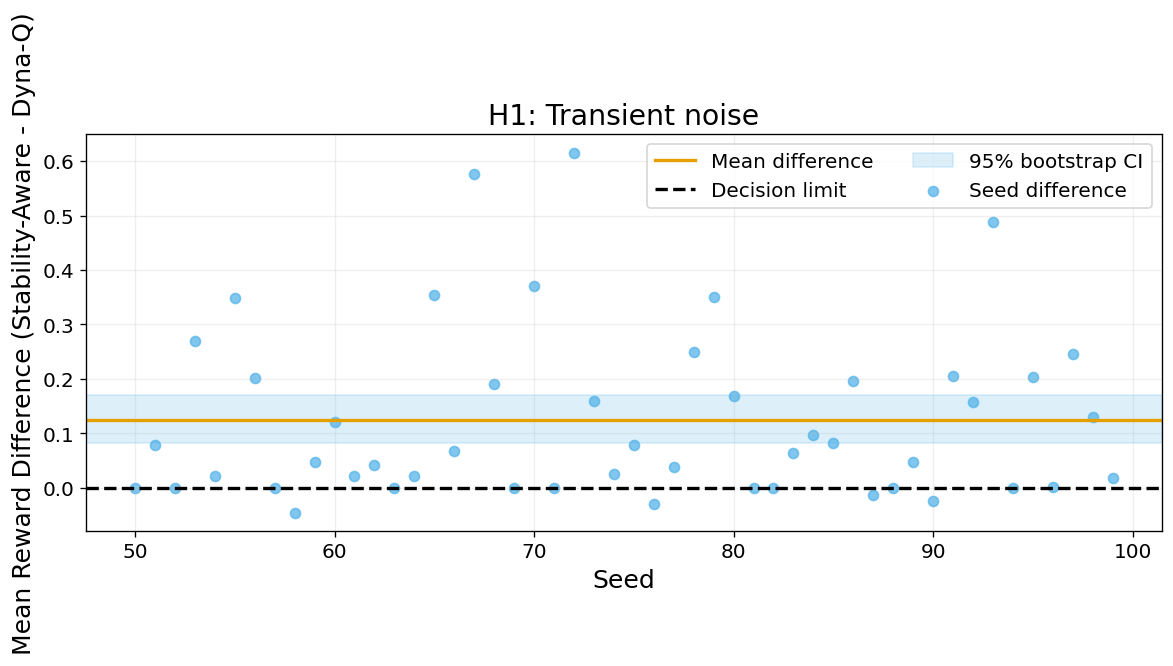

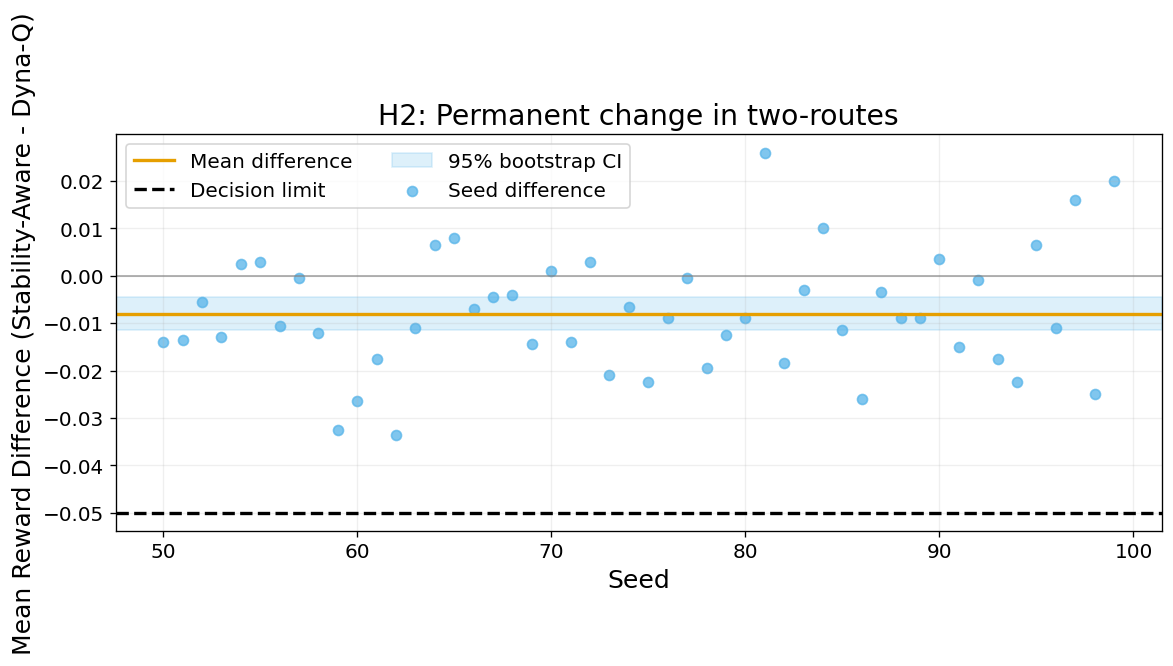

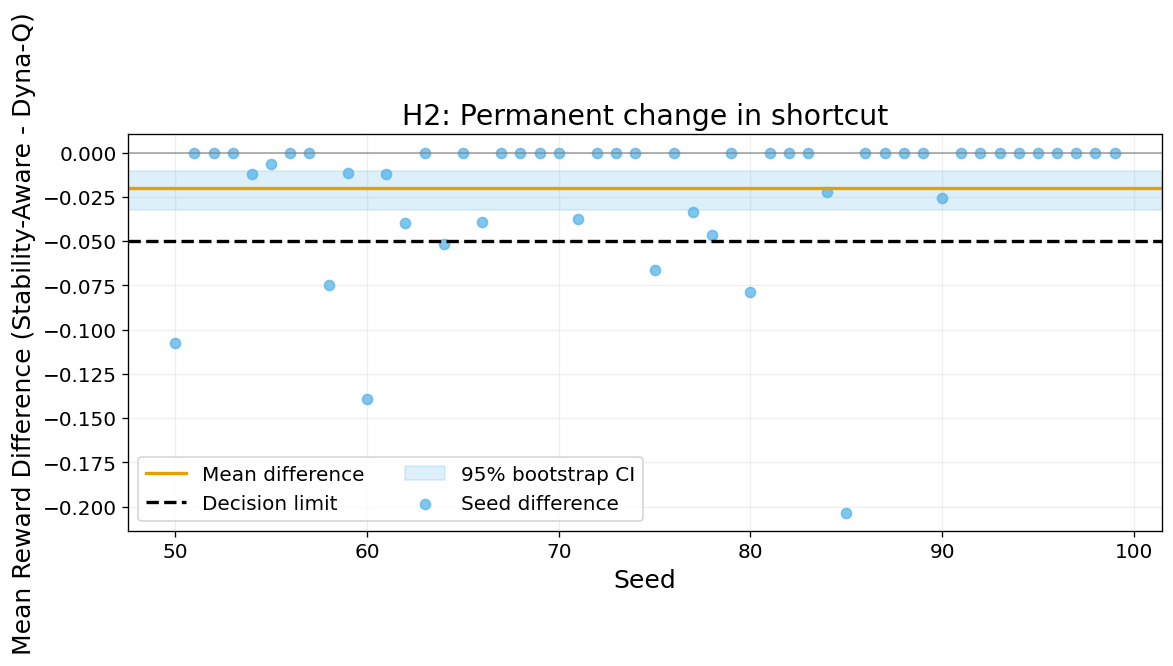

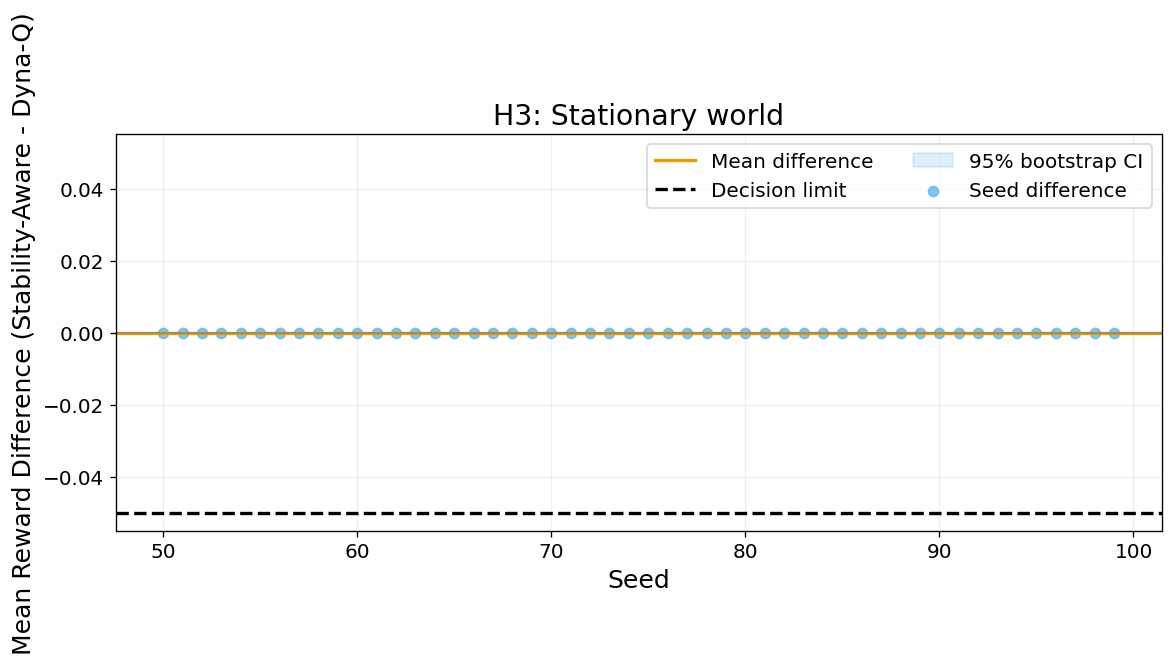

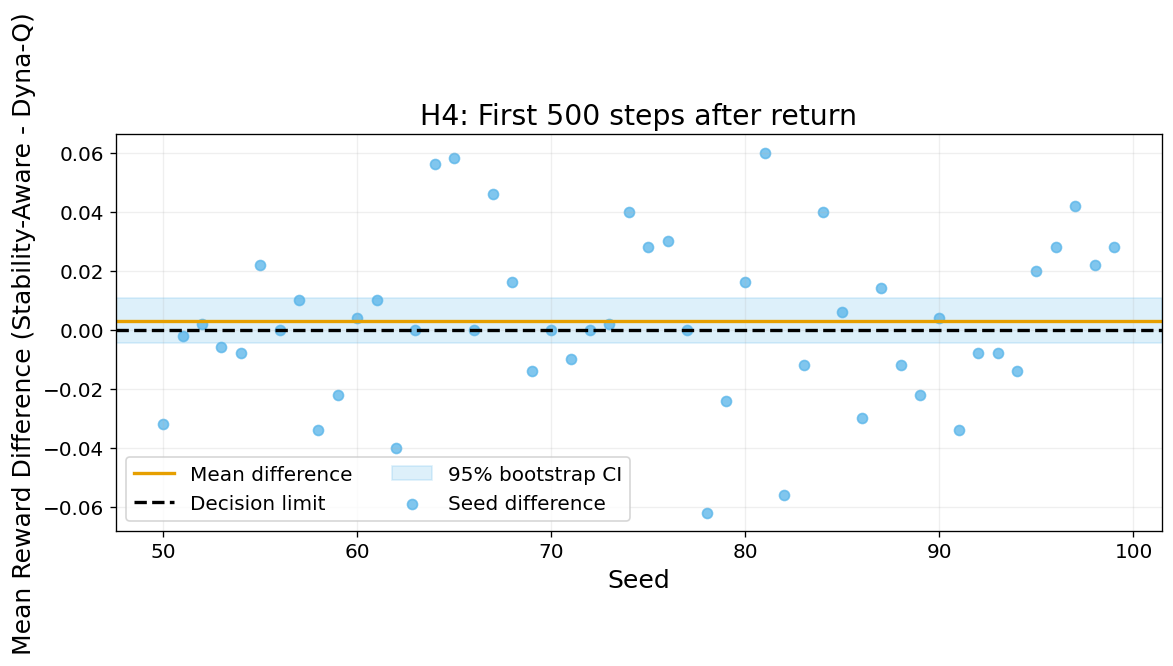

In [10]:
for result in primary_results.itertuples(index=False):
    differences = primary_differences[result.test_id]
    figure, axis = plt.subplots(figsize=(10, 4.5))
    axis.scatter(
        differences.index,
        differences.to_numpy(),
        color="#56B4E9",
        alpha=0.75,
        label="Seed difference",
    )
    axis.axhspan(
        result.ci_low,
        result.ci_high,
        color="#56B4E9",
        alpha=0.2,
        label="95% bootstrap CI",
    )
    axis.axhline(
        result.mean_difference,
        color="#E69F00",
        linewidth=2,
        label="Mean difference",
    )
    axis.axhline(
        result.decision_limit,
        color="black",
        linestyle="--",
        label="Decision limit",
    )
    if result.decision_limit != 0:
        axis.axhline(0, color="grey", linewidth=1, alpha=0.7)

    axis.set(
        title=f"{result.hypothesis}: {result.scenario}",
        xlabel="Seed",
        ylabel="Mean Reward Difference (Stability-Aware - Dyna-Q)",
    )
    axis.legend(ncol=2)
    axis.grid(alpha=0.2)
    figure.tight_layout()
    plt.show()